In [3]:
import qcodes

from qcodes.dataset import (
    LinSweep,
    Measurement,
    dond,
    experiments,
    initialise_or_create_database_at,
    load_by_run_spec,
    load_or_create_experiment,
    plot_dataset,
)

import matplotlib.pyplot as plt
from matplotlib import cm, colors

import numpy as np
import pandas as df
import time

from scipy.optimize import curve_fit
import pathlib

from pyCircFit_main import *

In [4]:
def circle_fit(freq,re,im,power,plotResults=True):

    # adapted from Kaushal's code to circle fit S21 data 
    amp_array = re+1j*im
    phase = np.unwrap(np.angle(amp_array))

    phase_corr=False
    if phase_corr:
        phase = np.unwrap(np.angle(amp_array))
        line_delay = (phase[0]-phase[-1])/(freq[0]-freq[-1])
        phase_corr_array = -phase[0]-line_delay*(freq-freq[0])
        amp_corr_array = amp_array * np.exp(1j*phase_corr_array)
        q_corr = np.imag(amp_corr_array)
        i_corr = np.real(amp_corr_array)
        mag_corr = np.sqrt(q_corr**2 + i_corr**2)
        phase_correct = np.unwrap(np.angle(amp_corr_array))
        plt.figure(11)
        plt.scatter(freq,10*np.log10(mag_corr))
        plt.figure(22)
        plt.scatter(freq,phase_correct)
        plt.figure(33)
        plt.scatter(i_corr,q_corr)
        plt.gca().set_aspect('equal')
        cresults = circlefit(freq/1e6, i_corr, q_corr,fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
        fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
    
    i_corr = re
    q_corr = im
    cresults = circlefit(freq/1e6, re, im, fittype='hanger', plotlabel='test', plot_detail = False, print_results=False, show_plots=False, fitQscl=1, fano = True)
    fit_data = S21_hanger(cresults['a'], cresults['alpha'], 0, cresults['fr'], 
                            cresults['Qtot'], cresults['Qc'], cresults['phi'], freq/1e6)
        
        # from Kaushal's code to calculate photon number 
    h = 6.63*1e-34
    q = np.abs(cresults['Qtot'])
    q_err = cresults['Qtot_stderr']
    qc = cresults['Qc']
    qc_err = np.abs(cresults['Qc_stderr'])
    qi = cresults['Qi']
    qi_err = np.abs(cresults['Qi_stderr'])
    f = cresults['fr']*1e6
    f_err = cresults['fr_stderr']
    a = cresults['a']

    # plotting results 
    if (plotResults):
        ## from Kaushal's code to plot circle fit
        plt.figure(figsize=(6,6))
        plt.scatter(i_corr, q_corr, label= 'IQ data', s=12)
        plt.plot(np.real(fit_data), np.imag(fit_data), label='IQ fit', linewidth=6, color='C2')
        plt.legend(fontsize=14, loc='upper right')
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.xlabel('I (a.u.)', fontsize=12)
        plt.ylabel('Q (a.u.)', fontsize=12)
        plt.title(r'$\bf{f}$'+f' = {np.round(cresults["fr"]*1e-3,4)} GHz' + r'$\pm $' + 
            f'{np.round(cresults['fr_stderr']*1e3,1)} KHz,' + r'$\bf{Q}_i$' + f' = {np.abs(np.round(cresults["Qi"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qi_stderr'],1)},'  + r'$\bf{Q}_c$' + f' = {np.abs(np.round(cresults["Qc"],1))}' + r'$\pm $' + 
            f'{np.round(cresults['Qc_stderr'],1)}', fontsize=12)
        plt.gca().set_aspect('equal')
        plt.show()
    
    #returns results for quantities
    return q,q_err,qc,qc_err,qi,qi_err,f,f_err,a

In [5]:
%config InlineBackend.figure_format = 'retina'
plt.rcParams['image.cmap'] = 'summer'

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Source Sans Pro'] + plt.rcParams['font.sans-serif']

In [6]:
db_path = pathlib.Path(r"C:\Users\emmag\OneDrive\Desktop\experiments.db")
db=initialise_or_create_database_at(db_path)

In [7]:
def load_band_2d(ds, name):
    """Return (gate [n], freq [m], s21 [n, m]) for one band."""
    d = ds.get_parameter_data(f"{name}_real", f"{name}_imag")
    re_block, im_block = d[f"{name}_real"], d[f"{name}_imag"]

    gate = re_block["gate"][:, 0]              # setpoint name; see note below
    freq = re_block[f"{name}_freq"][0, :]      # identical for every row
    s21 = re_block[f"{name}_real"] + 1j * im_block[f"{name}_imag"]
    return gate, freq, s21

def segment_freq_sweep(freq,s21,segment):
    if segment is not None:
            f_lo, f_hi = sorted(segment)
            mask = (freq >= f_lo) & (freq <= f_hi)
            if not mask.any():
                raise ValueError(
                    f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                    f"range {freq.min():.4g}–{freq.max():.4g} Hz"
                )
            freq = freq[mask]
            s21 = s21[mask]
    return freq, s21

def neg_lorentzian(f, f0, fwhm, depth, offset):
    return offset - depth / (1.0 + ((f - f0) / (0.5 * fwhm)) ** 2)

In [8]:
def collapse_rows(arr, *, report=True):
    """Average each row of a 2-D array. Returns (mean, std) per row."""
    arr = np.asarray(arr, dtype=float)
    if arr.ndim == 1:
        return arr, np.zeros_like(arr)
    if arr.ndim != 2:
        raise ValueError(f"expected 2-D, got shape {arr.shape}")

    mean = np.nanmean(arr, axis=1)
    std = np.nanstd(arr, axis=1)

    if report:
        bad = np.isnan(arr).sum()
        worst = np.nanmax(std / np.abs(mean)) if np.all(mean != 0) else np.nan
        print(f"{arr.shape} -> {mean.shape}; "
              f"max within-row scatter {worst:.2%}"
              + (f"; {bad} NaNs ignored" if bad else ""))
    return mean, std

In [ ]:
guid='599ab6e7-0000-0000-0000-01a09402fef3'
ds = qcodes.dataset.load_by_guid(guid)
ds.get_parameter_data()['TomTomTom_mxc_temperature']['TomTomTom_mxc_temperature'].shape
xds = ds.to_xarray_dataset()

(13, 29) -> (13,); max within-row scatter 10.77%


In [11]:
T_meas = ds.get_parameter_data()['TomTomTom_mxc_temperature']['TomTomTom_mxc_temperature']
T, T_std = collapse_rows(T_meas)

(13, 29) -> (13,); max within-row scatter 10.77%


In [12]:
gate_setpoints = xds.coords['gate'].values
temp_setpoints = xds.coords['TomTomTom_mxc_setpoint'].values
freq_setpoints = xds.coords['sample_freq'].values

def segment_freq_sweep(freq,s21,segment):
    if segment is not None:
            f_lo, f_hi = sorted(segment)
            mask = (freq >= f_lo) & (freq <= f_hi)
            if not mask.any():
                raise ValueError(
                    f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                    f"range {freq.min():.4g}–{freq.max():.4g} Hz"
                )
            freq = freq[mask]
            s21 = s21[mask]
    return freq, s21

In [14]:
gate_setpoints = xds.coords['gate'].values
temp_setpoints = xds.coords['TomTomTom_mxc_setpoint'].values
freq_setpoints = xds.coords['sample_freq'].values

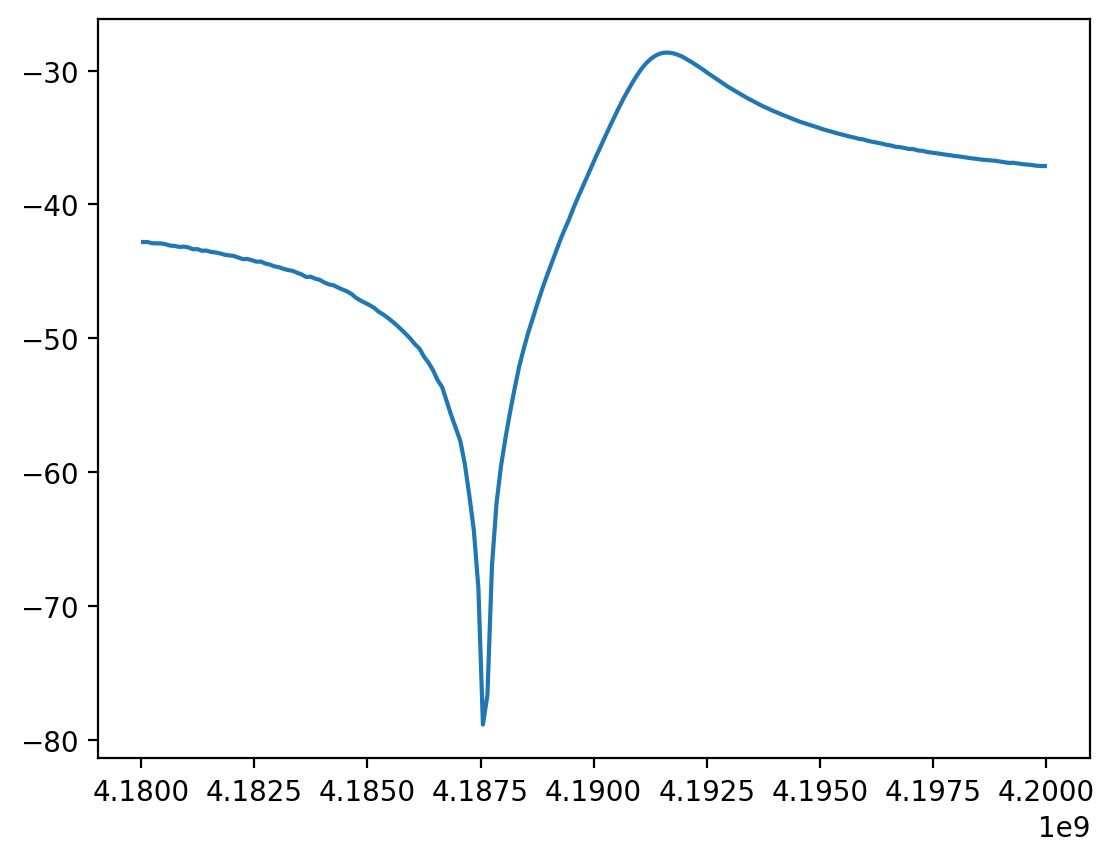

In [ ]:
tr_real= xds["sample_real"].sel({"gate": 0, "TomTomTom_mxc_setpoint": 0}, method="nearest").values
tr_imag= xds["sample_imag"].sel({"gate": 0, "TomTomTom_mxc_setpoint": 0}, method="nearest").values
s21 = tr_real+1j*tr_imag
seg_freq, seg_s21 = segment_freq_sweep(freq_setpoints,s21,segment=(3.275e9,3.30e9))
plt.plot(seg_freq,10*np.log10(np.abs(seg_s21)**2))
# plt.plot(np.real(seg_s21),np.imag(seg_s21))

Text(0.5, 0, 'Gate Bias (V)')

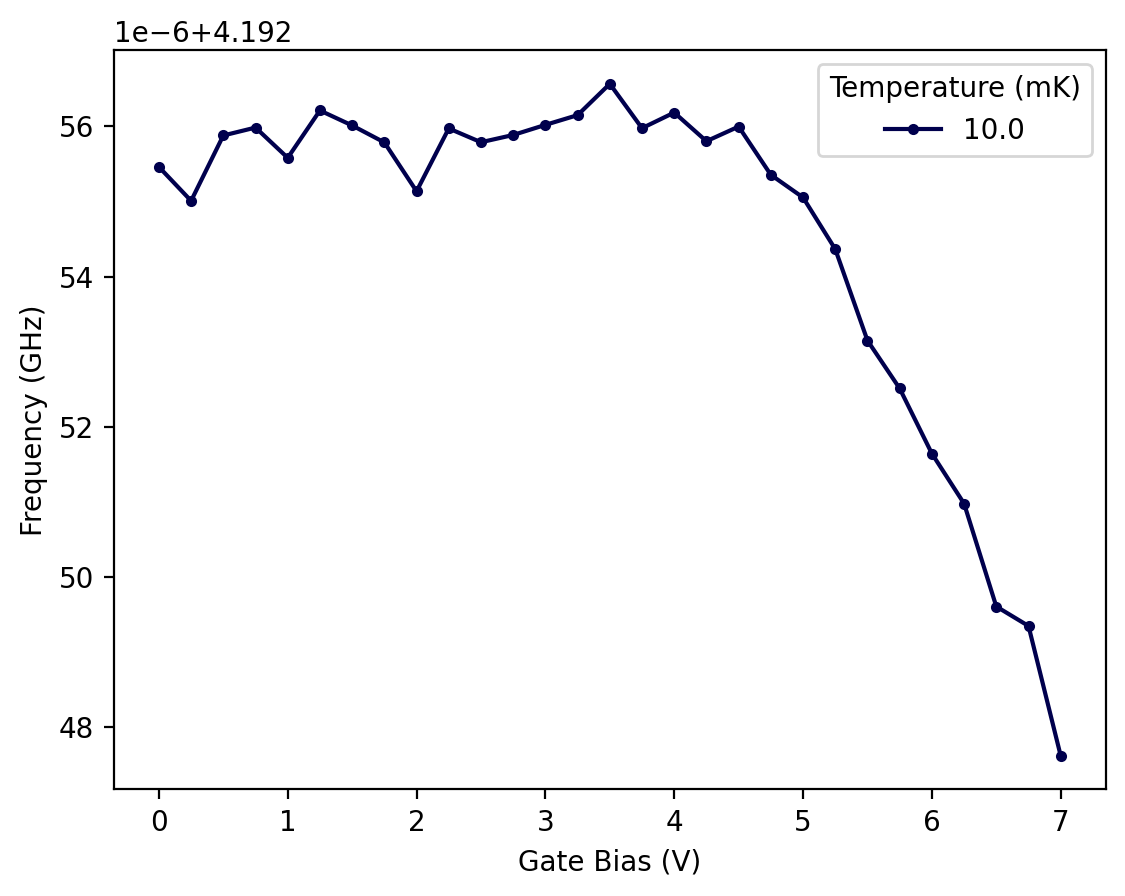

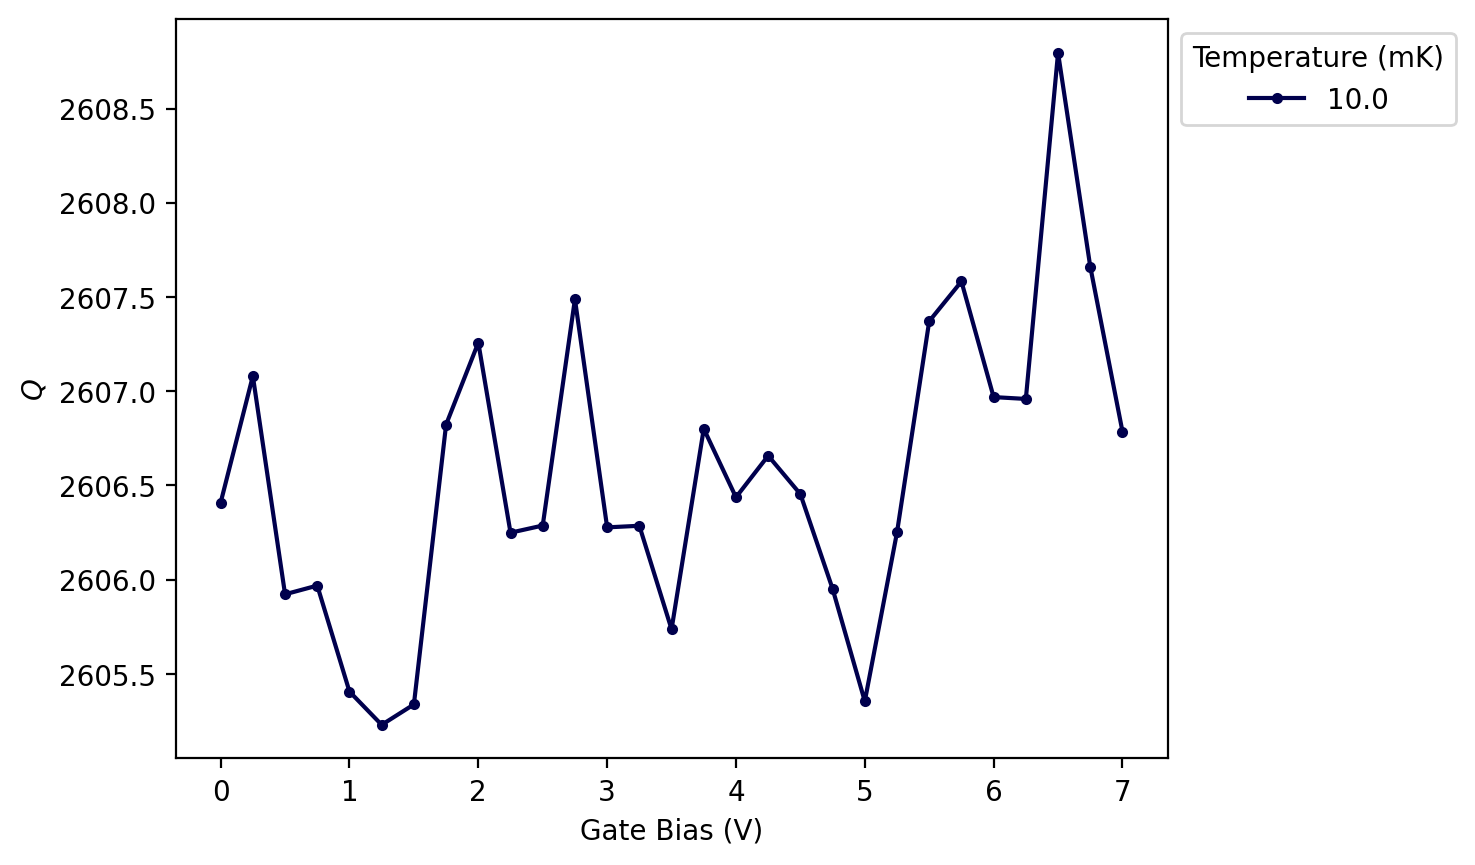

In [493]:
def segment_freq_sweep(freq,s21,segment):
    if segment is not None:
            f_lo, f_hi = sorted(segment)
            mask = (freq >= f_lo) & (freq <= f_hi)
            if not mask.any():
                raise ValueError(
                    f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                    f"range {freq.min():.4g}–{freq.max():.4g} Hz"
                )
            freq = freq[mask]
            s21 = s21[mask]
    return freq, s21
colors = colorset(len(T),cmap='seismic')
freq_setpoints = xds.coords['lambda4_freq'].values
for idx in range(1):
    temp_setpoint = temp_setpoints[idx]
    temp_actual = T[idx]
    q_arr = []
    f0_arr = []
    for g in gate_setpoints:
        tr_real= xds["lambda4_real"].sel({"gate": g, "TomTomTom_mxc_setpoint": temp_setpoint}, method="nearest").values
        tr_imag= xds["lambda4_imag"].sel({"gate": g, "TomTomTom_mxc_setpoint": temp_setpoint}, method="nearest").values
        s21 = tr_real+1j*tr_imag

        seg_freq, seg_s21 = segment_freq_sweep(freq_setpoints,s21,segment=(4.180e9,4.2e9))

        try:
            q,q_err,qc,qc_err,qi,qi_err,f,f_err,a = circle_fit(seg_freq,np.real(seg_s21),np.imag(seg_s21),power=-80,plotResults=False)
            q_arr.append(q)
            f0_arr.append(f)
        except:
            print("Fail!")
    plt.figure(1)
    plt.plot(gate_setpoints,(np.array(f0_arr))/1e9,label=f'{np.round(1e3*temp_actual,0)}',c=colors[idx],marker='.')
    plt.figure(2)
    plt.plot(gate_setpoints,q_arr,label=f'{np.round(1e3*temp_actual,0)}',c=colors[idx],marker='.')

plt.figure(1)
plt.legend(bbox_to_anchor=(1,1),title='Temperature (mK)')
plt.ylabel("Frequency (GHz)")
plt.xlabel("Gate Bias (V)")

plt.figure(2)
plt.legend(bbox_to_anchor=(1,1),title='Temperature (mK)')
plt.ylabel("$Q$")
plt.xlabel("Gate Bias (V)")

In [437]:
import numpy as np
import matplotlib as mpl


def colorset(n, cmap="summer", *, lo=0.0, hi=1.0, hex=False, reverse=False):
    """N evenly spaced colors from a colormap.

    lo, hi   restrict the range sampled (0–1) to trim washed-out ends.
    hex      return '#rrggbb' strings instead of RGBA tuples.
    """
    if n < 1:
        raise ValueError(f"n must be >= 1, got {n}")
    cm = mpl.colormaps[cmap]
    pts = np.full(1, (lo + hi) / 2) if n == 1 else np.linspace(lo, hi, n)
    if reverse:
        pts = pts[::-1]
    cols = cm(pts)
    return [mpl.colors.to_hex(c) for c in cols] if hex else cols

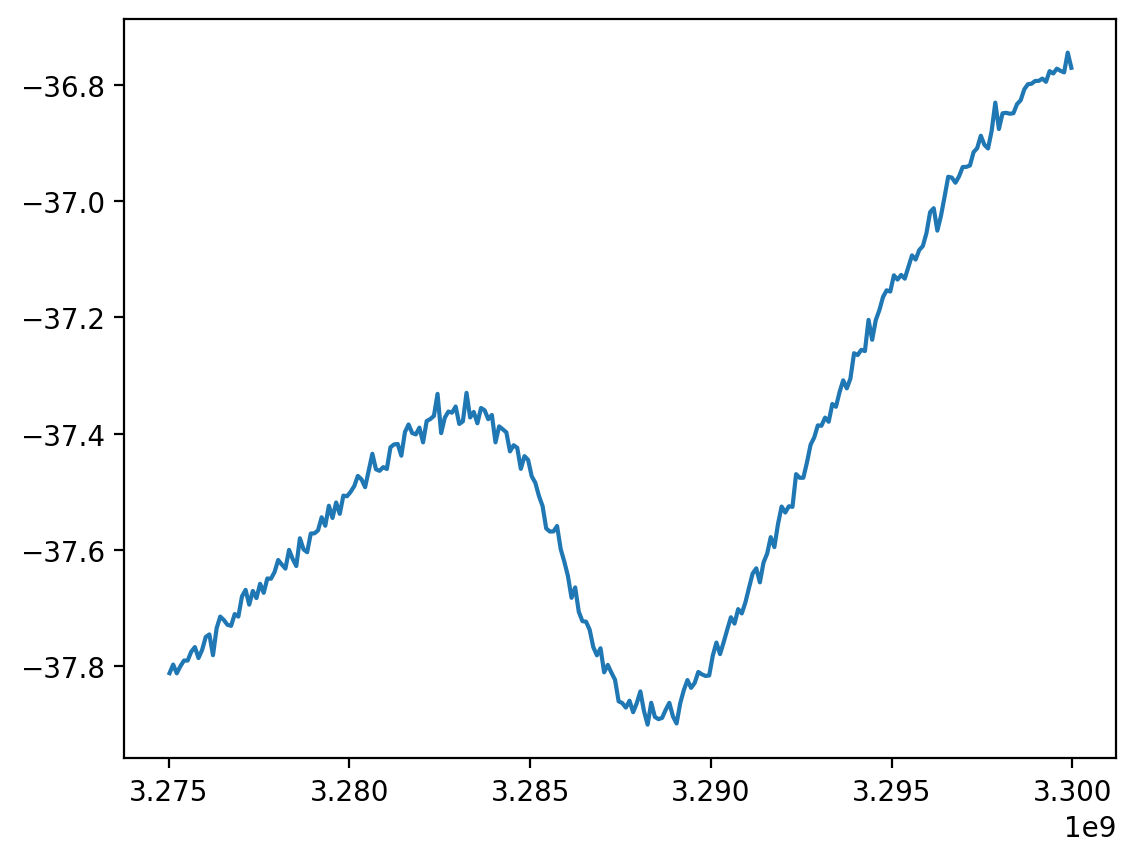

In [364]:
plt.plot(seg_freq,10*np.log10(np.abs(seg_s21)**2))

In [ ]:
# Each row is a gate bias.
ds.get_parameter_data('sample_real')['sample_real']['sample_real']

array([[ 0.01222533,  0.01214763,  0.0120111 , ..., -0.01223913,
        -0.01247117, -0.01275087],
       [ 0.01219308,  0.01217949,  0.01210938, ..., -0.0121967 ,
        -0.01250767, -0.01275581],
       [ 0.01219407,  0.012133  ,  0.0120621 , ..., -0.01221396,
        -0.01250464, -0.01274766],
       ...,
       [ 0.01216549,  0.01208917,  0.01199867, ..., -0.01182157,
        -0.01216988, -0.0124336 ],
       [ 0.01212818,  0.01210703,  0.01202426, ..., -0.01183027,
        -0.01215662, -0.01246364],
       [ 0.01215061,  0.01207688,  0.01201944, ..., -0.01187594,
        -0.01212465, -0.01242722]], shape=(352, 500))

In [307]:
ds.get_parameter_data()['TomTomTom_mxc_temperature'].keys()

dict_keys(['TomTomTom_mxc_temperature', 'TomTomTom_mxc_setpoint', 'gate'])

In [ ]:
def load_band_2d(ds, name):
    """Return (gate [n], freq [m], s21 [n, m]) for one band."""
    d = ds.get_parameter_data(f"{name}_real", f"{name}_imag")
    re_block, im_block = d[f"{name}_real"], d[f"{name}_imag"]

    gate = re_block["gate"][:, 0]              # setpoint name; see note below
    freq = re_block[f"{name}_freq"][0, :]      # identical for every row
    s21 = re_block[f"{name}_real"] + 1j * im_block[f"{name}_imag"]
    return gate, freq, s21

In [ ]:
gate, freq, s21 = load_band_2d(ds,'sample')
seg_freq, seg_s21 = segment_freq_sweep(freq,s21,segment=(3.275e9,3.30e9))

In [104]:
gate[28]

np.float64(0.0)

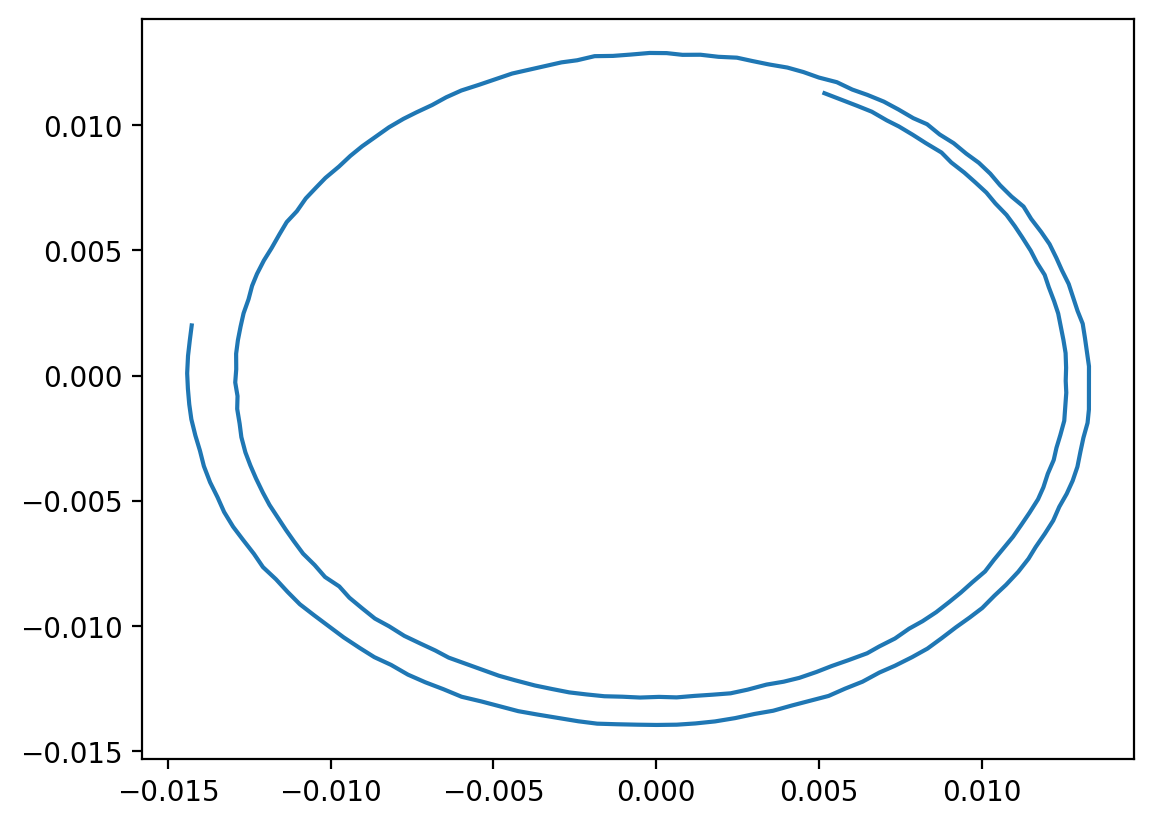

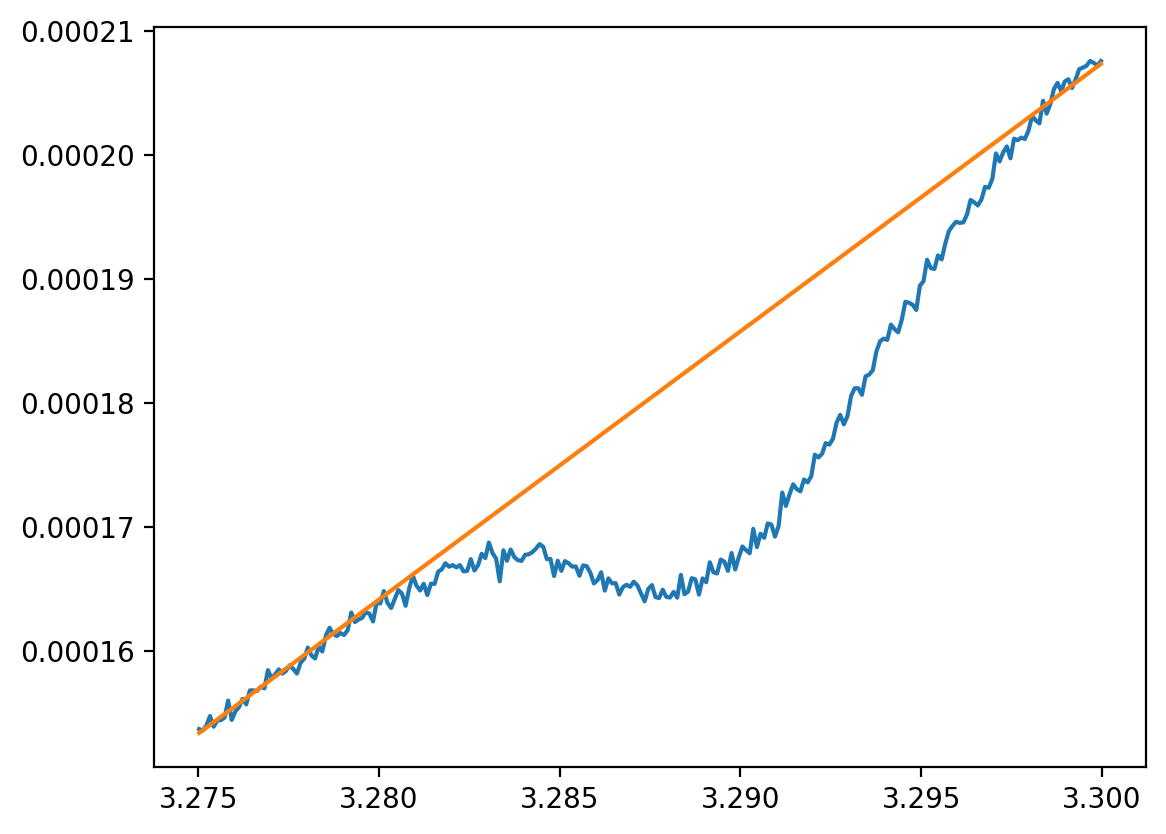

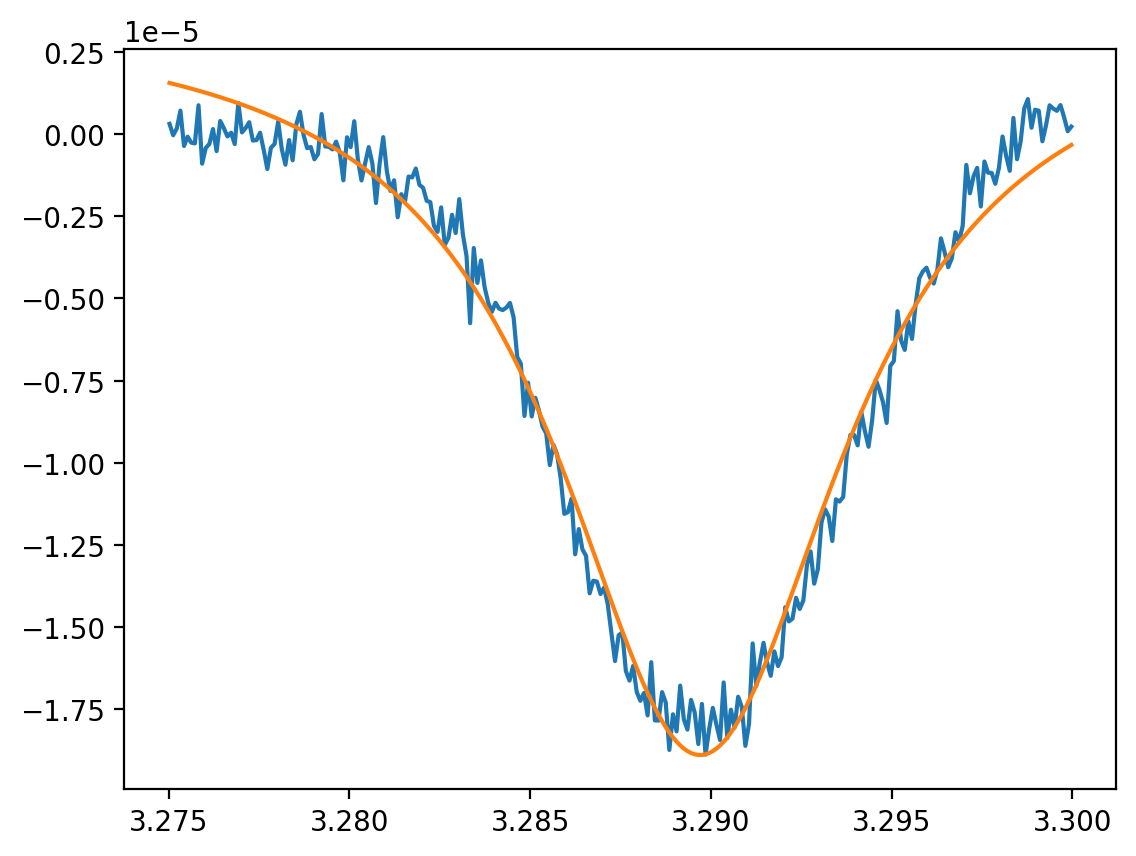

In [191]:
# Set background with gate = 0V.

seg = seg_s21[28]
plt.plot(np.real(seg),np.imag(seg))

plt.figure(2)

seg_power = np.abs(seg)**2
plt.plot(seg_freq/1e9,seg_power)

idx = 25
stitch_freq = np.concatenate((seg_freq[:idx], seg_freq[-idx:]))
stitch_seg = np.concatenate((seg_power[:idx], seg_power[-idx:]))

m,b=np.polyfit(stitch_freq/1e9,stitch_seg,1)
plt.plot(seg_freq/1e9,(m*seg_freq/1e9)+b)

plt.figure(3)

plt.plot(seg_freq/1e9,seg_power-(m*seg_freq/1e9+b))

guess = [3.290,0.01,1,-1]
popt,_ = curve_fit(neg_lorentzian,seg_freq/1e9,seg_power-(m*seg_freq/1e9+b),p0=guess)

plt.plot(seg_freq/1e9,neg_lorentzian(seg_freq/1e9,*popt))

BACKGROUND = m*seg_freq/1e9+b

M = m
B = b

53.544404220008985


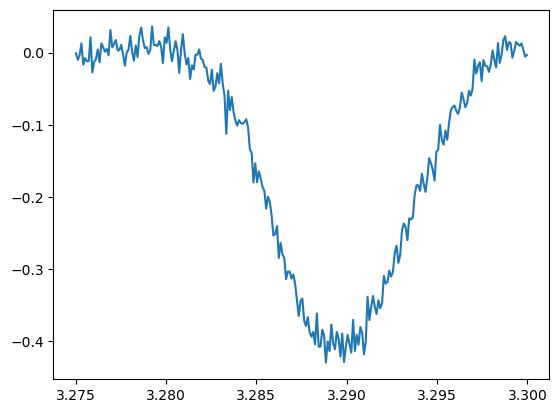

In [159]:
background = M*seg_freq/1e9+B
seg_dB = 10*np.log10(np.abs(seg)**2)
seg_background_substracted = seg_dB-background
plt.plot(seg_freq/1e9,seg_background_substracted)
min_idx = np.argmin(seg_background_substracted)
half_min = np.min(seg_background_substracted)/2
idx = np.arange(len(seg_background_substracted))
upper_half_idx = np.min(np.argwhere((seg_background_substracted>half_min) & (idx > min_idx)))
lower_half_idx = np.max(np.argwhere((seg_background_substracted>half_min) & (idx < min_idx)))
fwhm = seg_freq[upper_half_idx]/1e9-seg_freq[lower_half_idx]/1e9
print(np.abs(seg_background_substracted[min_idx])/fwhm)

In [216]:
# Use this to set the background subtraction for all traces.
f0_arr = []
q_arr = []
background = M*seg_freq/1e9+B

for idx,row in enumerate(seg_s21):
    # seg_dB = 10*np.log10(np.abs(row)**2)
    # seg_background_substracted = seg_dB-background

    # dip_min = np.min(seg_background_substracted)
    # threshold = 10*np.log10((1+10**(dip_min/10))/2) 

    # # Find minimum.
    # min_idx = np.argmin(seg_background_substracted)
    # idx_arr = np.arange(len(seg_background_substracted))

    # # Grab halfway points.
    # upper_half_idx = np.min(np.argwhere((seg_background_substracted>threshold) & (idx_arr > min_idx)))
    # lower_half_idx = np.max(np.argwhere((seg_background_substracted>threshold) & (idx_arr < min_idx)))
    # fwhm = seg_freq[upper_half_idx]/1e9-seg_freq[lower_half_idx]/1e9

    # f0 = seg_freq[min_idx]/1e9
    # q = np.abs(f0)/fwhm
    # f0_arr.append(f0)
    # q_arr.append(q)

    # seg_power = np.abs(row)**2
    # seg_background_substracted = seg_power-BACKGROUND

    # try:
    #     guess = [3.290,0.01,1,0]
    #     popt,_ = curve_fit(neg_lorentzian,seg_freq/1e9,seg_background_substracted,p0=guess)
    #     f0 = popt[0]
    #     q = popt[0]/popt[1]
    #     f0_arr.append(f0)
    #     q_arr.append(q)
    # except:
    #     print("Fail!")
    #     f0_arr.append(np.nan)
    #     q_arr.append(np.nan)

    # if idx < 10:
    #     plt.figure(idx)
    #     plt.plot(np.real(row),np.imag(row))

    try:
        q,q_err,qc,qc_err,qi,qi_err,f,f_err,a = circle_fit(seg_freq,np.real(row),np.imag(row),power=-80,plotResults=False)
        q_arr.append(qi)
        f0_arr.append(f)
    except:
        print("Could not fit!")

# for idx,row in enumerate(seg_s21):
    # try:
    #     guess = [3.290,0.01,1,0]
    #     popt,_ = curve_fit(neg_lorentzian,seg_freq/1e9,10*np.log10(np.abs(row)**2)-background,p0=guess)
    #     f0 = popt[0]
    #     q = popt[0]/popt[1]
    #     f0_arr.append(f0)
    #     q_arr.append(q)
    # except:
    #     print("Fail!")
    #     f0_arr.append(np.nan)
    #     q_arr.append(np.nan)

In [297]:
"""Extract (T, gate, freq, s21) from a gate-bias / temperature sweep.

Self-contained: depends only on numpy and xarray.
"""

from collections import namedtuple

import numpy as np
import xarray as xr

Sweep = namedtuple("Sweep", "T gate freq s21")

# Candidate coordinate names, checked in order, case-insensitive.
_TEMP_NAMES = ("t", "temp", "temperature", "mxc", "mxc_temp", "t_mxc")
_GATE_NAMES = ("gate", "vg", "v_g", "gate_v", "gate_bias", "vbias", "bias")
_FREQ_NAMES = ("freq", "frequency", "freq_hz", "f", "rf_freq")

_REAL_IMAG = (("real", "imag"), ("re", "im"), ("i", "q"), ("s21_real", "s21_imag"))
_MAG_PHASE = (("mag", "phase"), ("magnitude", "phase"), ("amp", "phase"),
              ("s21_mag", "s21_phase"))


def _find_dim(obj, candidates, override, what):
    """Resolve a dimension name, preferring an explicit override."""
    if override is not None:
        if override not in obj.dims:
            raise KeyError(f"{override!r} is not a dim; available: {tuple(obj.dims)}")
        return override
    lowered = {str(d).lower(): d for d in obj.dims}
    for name in candidates:
        if name in lowered:
            return lowered[name]
    raise KeyError(
        f"could not identify the {what} dim among {tuple(obj.dims)}; "
        f"pass {what}_dim= explicitly"
    )


def _as_complex(obj, var=None):
    """Collapse a Dataset to a single complex DataArray."""
    if isinstance(obj, xr.DataArray):
        return obj

    names = list(obj.data_vars)
    lowered = {n.lower(): n for n in names}

    if var is not None:
        return obj[var]
    if len(names) == 1:
        return obj[names[0]]

    for a, b in _REAL_IMAG:
        if a in lowered and b in lowered:
            da = obj[lowered[a]] + 1j * obj[lowered[b]]
            return da.assign_attrs(obj.attrs)
    for a, b in _MAG_PHASE:
        if a in lowered and b in lowered:
            da = obj[lowered[a]] * np.exp(1j * obj[lowered[b]])
            return da.assign_attrs(obj.attrs)

    for n in names:
        if np.iscomplexobj(obj[n].values):
            return obj[n]

    raise ValueError(f"pass var= to pick the S21 variable; candidates are {names}")


def load_gate_sweep(
    obj, temperature=None, *, var=None,
    temp_dim=None, gate_dim=None, freq_dim=None,
    f_window=None, gate_window=None, sort=True,
):
    """Return a Sweep(T, gate, freq, s21) for the selected temperatures.

    obj          xarray Dataset or DataArray holding complex S21.
    temperature  None                -> every temperature in the sweep
                 scalar              -> the single nearest temperature
                 (lo, hi) tuple      -> every temperature in [lo, hi]
                 list/array          -> the nearest match to each value
    f_window     (lo, hi) in the frequency coord's own units, or None.
    gate_window  (lo, hi) in volts, or None.

    s21 has shape (n_T, n_gate, n_freq) and is always complex and 3-D,
    even when a single temperature is selected.
    """
    da = _as_complex(obj, var)

    t_dim = _find_dim(da, _TEMP_NAMES, temp_dim, "temp")
    g_dim = _find_dim(da, _GATE_NAMES, gate_dim, "gate")
    f_dim = _find_dim(da, _FREQ_NAMES, freq_dim, "freq")

    # --- temperature selection -------------------------------------------
    if temperature is None:
        sel = da
    elif isinstance(temperature, tuple) and len(temperature) == 2:
        lo, hi = sorted(temperature)
        sel = da.sel({t_dim: slice(lo, hi)})
        if sel.sizes[t_dim] == 0:      # coord may be stored descending
            sel = da.sel({t_dim: slice(hi, lo)})
        if sel.sizes[t_dim] == 0:
            rng = da.coords[t_dim].values
            raise ValueError(
                f"no temperatures in [{lo}, {hi}]; data spans "
                f"[{np.nanmin(rng)}, {np.nanmax(rng)}]"
            )
    else:
        want = np.atleast_1d(np.asarray(temperature, dtype=float))
        sel = da.sel({t_dim: want}, method="nearest")

    if sel.ndim == 2:                  # scalar .sel dropped the temp dim
        sel = sel.expand_dims(t_dim)

    sel = sel.transpose(t_dim, g_dim, f_dim)

    T = np.atleast_1d(np.asarray(sel.coords[t_dim].values, dtype=float))
    gate = np.asarray(sel.coords[g_dim].values, dtype=float)
    freq = np.asarray(sel.coords[f_dim].values, dtype=float)
    s21 = np.asarray(sel.values).astype(complex)

    # --- windowing ---------------------------------------------------------
    if gate_window is not None:
        lo, hi = sorted(gate_window)
        m = (gate >= lo) & (gate <= hi)
        if not m.any():
            raise ValueError(f"gate_window {gate_window} selects nothing")
        gate, s21 = gate[m], s21[:, m, :]

    if f_window is not None:
        lo, hi = sorted(f_window)
        m = (freq >= lo) & (freq <= hi)
        if not m.any():
            raise ValueError(
                f"f_window {f_window} selects nothing; freq spans "
                f"[{freq.min():.6g}, {freq.max():.6g}] — check Hz vs GHz"
            )
        freq, s21 = freq[m], s21[..., m]

    # --- ordering ----------------------------------------------------------
    if sort:
        for axis, arr in ((0, T), (1, gate), (2, freq)):
            if arr.size > 1 and arr[0] > arr[-1]:
                order = np.argsort(arr)
                arr[:] = arr[order]
                s21 = np.take(s21, order, axis=axis)

    return Sweep(T, gate, freq, s21)


if __name__ == "__main__":
    # Synthetic check: two temperatures, a gate-dependent resonance.
    n_t, n_g, n_f = 2, 5, 401
    T = np.array([0.020, 0.150])
    gate = np.linspace(-2.0, 2.0, n_g)
    freq = np.linspace(5.90e9, 6.10e9, n_f)

    f0 = 6.0e9 + 2e6 * gate[None, :, None]
    ql = 2e4 / (1 + 4 * T[:, None, None])
    x = (freq[None, None, :] - f0) / f0
    s21 = 1 - (ql / 3e4) / (1 + 2j * ql * x)

    ds = xr.Dataset(
        {"s21": (("T", "gate", "freq"), s21)},
        coords={"T": T, "gate": gate, "freq": freq},
    )

    sw = load_gate_sweep(ds, (0.0, 0.1), f_window=(5.98e9, 6.02e9))
    print("T    ", sw.T)
    print("gate ", sw.gate)
    print("freq ", sw.freq[0], "->", sw.freq[-1], f"({sw.freq.size} pts)")
    print("s21  ", sw.s21.shape, sw.s21.dtype)

T     [0.02]
gate  [-2. -1.  0.  1.  2.]
freq  5980000000.0 -> 6020000000.0 (81 pts)
s21   (1, 5, 81) complex128


In [ ]:
def segment_freq_sweep(freq,s21,segment):
    if segment is not None:
            f_lo, f_hi = sorted(segment)
            mask = (freq >= f_lo) & (freq <= f_hi)
            if not mask.any():
                raise ValueError(
                    f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                    f"range {freq.min():.4g}–{freq.max():.4g} Hz"
                )
            freq = freq[mask]
            s21 = s21[:,mask]
    return freq, s21

ds = qcodes.load_by_guid('03b6b17b-0000-0000-0000-01a098460236')
gate, freq, s21 = load_band_2d(ds,'sample')
seg_freq, seg_s21 = segment_freq_sweep(freq,s21,segment=(3.275e9,3.30e9))

C:\Users\emmag\AppData\Local\Temp\ipykernel_9480\3178879957.py:14: QCoDeSDeprecationWarning: Importing 'load_by_guid' from the top level 'qcodes' namespace is deprecated. Import it from 'qcodes.dataset' instead.
  ds = qcodes.load_by_guid('03b6b17b-0000-0000-0000-01a098460236')


<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:23: SyntaxWarning: invalid escape sequence '\D'
<>:25: SyntaxWarning: invalid escape sequence '\p'
C:\Users\emmag\AppData\Local\Temp\ipykernel_9480\1828250326.py:23: SyntaxWarning: invalid escape sequence '\D'
  ax1.set_ylabel("Extracted $\Delta f_0$ (MHz)",c='blue')
C:\Users\emmag\AppData\Local\Temp\ipykernel_9480\1828250326.py:25: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Q versus gate bias at base temperature \n showing kinks above $\pm$ 2V.")


Text(0.5, 1.0, 'Q versus gate bias at base temperature \n showing kinks above $\\pm$ 2V.')

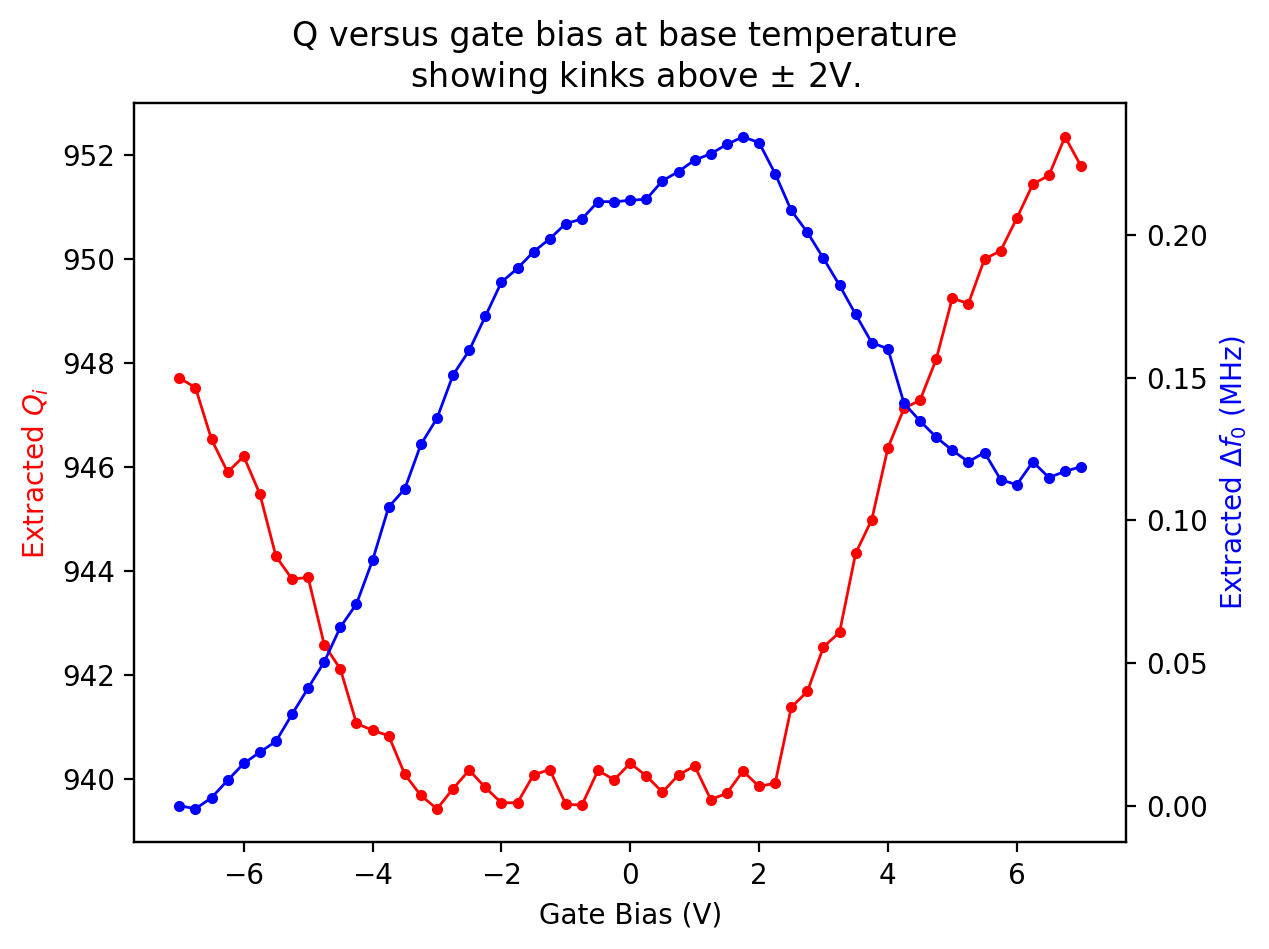

In [ ]:
# Use this to set the background subtraction for all traces.
f0_arr = []
q_arr = []
background = M*seg_freq/1e9+B

for idx,row in enumerate(seg_s21):

    try:
        q,q_err,qc,qc_err,qi,qi_err,f,f_err,a = circle_fit(seg_freq,np.real(row),np.imag(row),power=-80,plotResults=False)
        q_arr.append(qi)
        f0_arr.append(f)
    except:
        print("Could not fit!")

# plt.plot(gate,np.array(f0_arr)/1e9)
fig, ax = plt.subplots(1)
ax.plot(gate,np.array(np.abs(q_arr)),c='red',marker='.',linewidth=1)
ax.set_xlabel('Gate Bias (V)')
ax.set_ylabel("Extracted $Q_i$",c='red')

ax1 = ax.twinx()
ax1.plot(gate,(np.array(f0_arr)-f0_arr[0])/1e6,c='blue',marker='.',linewidth=1)
ax1.set_ylabel("Extracted $\Delta f_0$ (MHz)",c='blue')

plt.title("Q versus gate bias at base temperature \n showing kinks above $\pm$ 2V.")

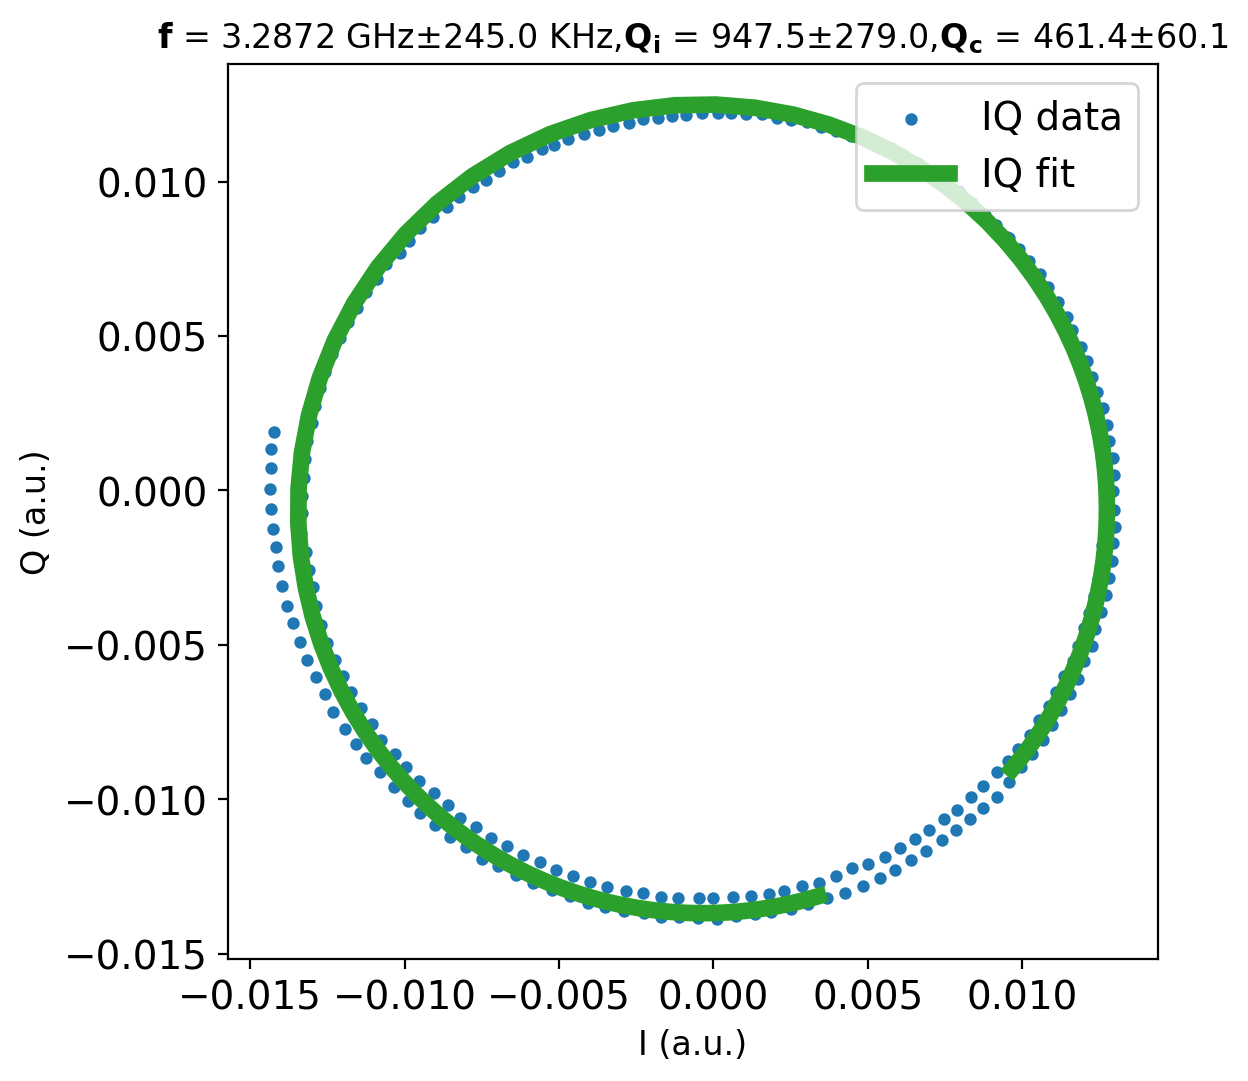

(np.float64(901.4674680313294),
 np.float64(105.6692206670569),
 np.float64(461.4476449659475),
 np.float64(60.12516410852675),
 np.float64(-947.4852517320643),
 np.float64(279.01296189924216),
 np.float64(3287163686.5247054),
 np.float64(0.24498704336015367),
 np.float64(0.013408902539144429))

In [207]:
circle_fit(seg_freq,np.real(seg_s21[1]),np.imag(seg_s21[0]),power=-80)

In [404]:
"""
Plotting helpers for the temperature / gate / frequency sweep produced by:

    result = dond(temp_sweep, gate_sweep,
                  smu.curr, tom.mxc_temperature,
                  *[p for b in bands for p in (b.acquire, b.real, b.imag)],
                  ...)

The measured mixing-chamber temperature is recorded as a *dependent* parameter
on the (setpoint, gate) grid, not as an axis.  SweepData pulls it out, averages
it over the gate axis at each outer step, and promotes it to a real coordinate
called "T" so both maps are plotted against measured temperature rather than
the PID setpoint.

Band names
----------
A band is identified by the *full* parameter name up to its "_real" / "_imag"
suffix, so "sample_lambda2_real" belongs to band "sample_lambda2".  Names are
matched exactly, which keeps bands that share a prefix -- "sample_a" and
"sample_a_wide", say -- from being confused with one another.  band_names()
lists what a run actually contains; pass one of those strings to the plotting
functions.  Override the suffixes with SweepData(..., component_suffixes=...)
if a setup labels the two halves differently.

Usage
-----
    sd = SweepData.from_dond(result)
    print(sd.summary())
    print(sd.band_names())        # e.g. ['sample_lambda2', 'sample_lambda3']

    plot_freq_vs_gate(sd, "lambda2", temperature=0.150)   # nearest measured T
    plot_freq_vs_temp(sd, "lambda2", gate=-1.5)           # nearest gate value

Each map has a line-cut counterpart taking the same selection argument, with
one trace per step of the other axis:

    plot_linecuts_vs_gate(sd, "lambda2", temperature=0.150,
                          gates=[-2.0, -1.5, -1.0, -0.5, 0.0])
    plot_linecuts_vs_temp(sd, "lambda2", gate=-1.5)

Zooming and baseline removal
----------------------------
Every plotting function takes:

    segment=(f_lo, f_hi)    frequency window in **Hz**, e.g. (6e9, 7e9)
    detrend="edges"         fit and subtract a line in frequency, independently
                            for each column (each gate step or each temperature
                            step), leaving deviation from the local baseline
    edge_frac=0.15          fraction of points at each end used for the fit
                            when detrend="edges"

    plot_freq_vs_gate(sd, "lambda2", temperature=0.150,
                      segment=(6e9, 7e9), detrend="edges")

detrend="full" fits over every point in the segment instead.  Prefer "edges"
whenever a resonance sits inside the window: a full-span fit is pulled toward
the dip, so subtraction leaves a spurious slope that moves with the resonance.

The fitted slopes (dB/GHz, or deg/GHz for phase) are attached to the returned
mesh as ``mesh.detrend_slopes`` (``ax.detrend_slopes`` for the line plots), one
per column.  They should be nearly constant; structure in them usually means
the fit window is catching the resonance.
"""

from __future__ import annotations

import warnings

import numpy as np
import matplotlib.pyplot as plt

QUANTITIES = ("mag_db", "mag", "phase", "real", "imag")

DETREND_MODES = (None, False, True, "full", "edges")

# Trailing markers that identify the two halves of a complex S-parameter.
# Lower-case keys; parameter names are matched case-insensitively.
COMPONENT_SUFFIXES = {"_real": "real", "_imag": "imag"}


# --------------------------------------------------------------------------
# name / dimension resolution
# --------------------------------------------------------------------------

def _find_one(keys, *fragments):
    """
    Return the single key containing all fragments (case-insensitive).

    Substring matching, so only safe for names that cannot be a prefix of one
    another -- used for the temperature parameter, not for bands.
    """
    frags = [f.lower() for f in fragments]
    hits = [k for k in keys if all(f in k.lower() for f in frags)]
    if len(hits) == 1:
        return hits[0]
    raise KeyError(
        f"expected exactly one parameter matching {fragments}, found {hits}. "
        f"Available: {sorted(keys)}"
    )


def _split_component(key, suffixes=COMPONENT_SUFFIXES):
    """
    Split a parameter name into (band, component) on a trailing "_real" or
    "_imag", or return (None, None) if it is not an S-parameter component.

    The band name is *everything* before the suffix, with its original case
    preserved, so "sample_lambda2_real" -> ("sample_lambda2", "real") and two
    bands sharing a "sample_" prefix stay distinct.  Matching the suffix at
    the end rather than anywhere in the string also keeps a parameter like
    "realtime_monitor" from being mistaken for a component.
    """
    low = key.lower()
    for suffix, component in suffixes.items():
        if low.endswith(suffix) and len(key) > len(suffix):
            return key[: len(key) - len(suffix)], component
    return None, None


def _index_components(keys, suffixes=COMPONENT_SUFFIXES):
    """Map band name -> {"real": key, "imag": key} for every component found."""
    found = {}
    for key in keys:
        band, component = _split_component(key, suffixes)
        if band is None:
            continue
        slot = found.setdefault(band, {})
        if component in slot:
            raise KeyError(
                f"two parameters both look like the {component!r} component of "
                f"band {band!r}: {slot[component]!r} and {key!r}"
            )
        slot[component] = key
    return found


class SweepData:
    """Lazily-converted view of the dond dataset, keyed by band name."""

    def __init__(
        self,
        dataset,
        temp_param="mxc_temperature",
        temp_dim=None,
        gate_dim=None,
        component_suffixes=None,
    ):
        self.dataset = dataset
        # One DataArray per dependent parameter.  Using the *dict* form rather
        # than to_xarray_dataset() matters here: the bands have different
        # numbers of frequency points (500/500/250), so a single merged
        # Dataset would pad everything to the longest axis with NaN.
        self.arrays = dataset.to_xarray_dataset_dict()

        self.component_suffixes = dict(component_suffixes or COMPONENT_SUFFIXES)

        # band name -> {"real": param, "imag": param}, resolved once so that
        # band lookup is an exact dict hit rather than a substring search.
        self._components = _index_components(self.arrays, self.component_suffixes)
        incomplete = {
            b: sorted(c) for b, c in self._components.items() if len(c) < 2
        }
        if incomplete:
            warnings.warn(
                "ignoring band(s) with a missing component: "
                + ", ".join(f"{b} (has only {c})" for b, c in incomplete.items())
            )

        self.temp_key = _find_one(self.arrays, temp_param)
        tkey = self.temp_key
        tda = self.arrays[tkey]
        if len(tda.dims) != 2:
            raise ValueError(
                f"expected {tkey} to live on a 2D (temperature, gate) grid, "
                f"got dims {tda.dims}"
            )

        # Work out which of the two grid dims is the temperature axis.
        if temp_dim is None:
            cand = [
                d for d in tda.dims
                if any(s in d.lower() for s in ("mxc", "setpoint", "temp"))
            ]
            if len(cand) != 1:
                raise ValueError(
                    f"could not identify the temperature dim among {tda.dims}; "
                    "pass temp_dim= and gate_dim= explicitly"
                )
            temp_dim = cand[0]
        if gate_dim is None:
            others = [d for d in tda.dims if d != temp_dim]
            gate_dim = others[0]

        self.temp_dim = temp_dim
        self.gate_dim = gate_dim

        # Measured temperature at each outer step, averaged over the gate
        # sweep (the inner loop runs at nominally fixed T).  The spread tells
        # you whether that average is meaningful.
        self._t_measured = tda.mean(dim=gate_dim, skipna=True)
        self._t_spread = (
            tda.max(dim=gate_dim, skipna=True) - tda.min(dim=gate_dim, skipna=True)
        )

        self.gate_values = np.asarray(tda.coords[gate_dim].values)
        self._band_cache = {}

    @classmethod
    def from_dond(cls, result, **kwargs):
        """Accept either the dond return tuple or a bare DataSet."""
        dataset = result[0] if isinstance(result, tuple) else result
        return cls(dataset, **kwargs)

    # -- temperature bookkeeping -------------------------------------------

    @property
    def temperatures(self):
        """Measured temperature per outer step, in setpoint order."""
        return np.asarray(self._t_measured.values)

    @property
    def temperature_spread(self):
        """max-min of measured T across the gate sweep, per outer step."""
        return np.asarray(self._t_spread.values)

    def summary(self):
        setp = np.asarray(self._t_measured.coords[self.temp_dim].values)
        lines = [f"{len(setp)} temperature steps, {len(self.gate_values)} gate points",
                 f"  {'setpoint':>12}  {'measured':>12}  {'spread':>10}"]
        for s, m, d in zip(setp, self.temperatures, self.temperature_spread):
            lines.append(f"  {s:>12.4g}  {m:>12.4g}  {d:>10.3g}")
        lines.append(f"bands: {', '.join(self.band_names())}")
        return "\n".join(lines)

    # -- band data ---------------------------------------------------------

    def band_names(self):
        """
        Full band names, i.e. the whole parameter name up to the "_real" /
        "_imag" suffix.  Bands sharing a prefix stay separate, so a run with
        "sample_a_real" and "sample_b_real" reports ["sample_a", "sample_b"].
        """
        return sorted(
            band for band, comp in self._components.items() if len(comp) == 2
        )

    def components(self, name):
        """The underlying parameter names for one band, as a dict."""
        return dict(self._components[self._resolve_band(name)])

    def _resolve_band(self, name):
        """
        Exact band name, with a case-insensitive fallback.

        Deliberately not a substring match: with bands named "sample_a" and
        "sample_a_wide", a substring search for "sample_a" hits both, and
        whichever one it picked would be a coin toss.
        """
        if name in self._components:
            return name

        ci = [b for b in self._components if b.lower() == name.lower()]
        if len(ci) == 1:
            return ci[0]

        available = sorted(self._components)
        near = [b for b in available if name.lower() in b.lower()]
        hint = (
            f" Did you mean one of {near}? Band names are now the full "
            "parameter name up to the component suffix, so pass it in full."
            if near else f" Available bands: {available}."
        )
        raise KeyError(f"no band named {name!r}.{hint}")

    def band(self, name):
        """
        Complex S-parameter for one band, as an xarray.DataArray with dims
        ("T", <gate>, <frequency>), sorted by ascending measured temperature.

        `name` must be the full band name as reported by band_names().
        """
        name = self._resolve_band(name)
        if name in self._band_cache:
            return self._band_cache[name]

        comp = self._components[name]
        missing = sorted({"real", "imag"} - set(comp))
        if missing:
            raise KeyError(
                f"band {name!r} has no {missing} component; found only "
                f"{sorted(comp.values())}"
            )

        rkey, ikey = comp["real"], comp["imag"]
        rda, ida = self.arrays[rkey], self.arrays[ikey]
        if rda.dims != ida.dims or rda.shape != ida.shape:
            # xarray would broadcast these into something plausible-looking
            raise ValueError(
                f"band {name!r}: {rkey!r} has dims {rda.dims} {rda.shape} but "
                f"{ikey!r} has {ida.dims} {ida.shape}"
            )

        da = rda + 1j * ida
        da.name = name

        missing = set(da.dims) - {self.temp_dim, self.gate_dim}
        if len(missing) != 1:
            raise ValueError(
                f"expected one frequency dim for band {name!r}, got {sorted(missing)}"
            )
        freq_dim = missing.pop()

        da = da.assign_coords({"T": (self.temp_dim, self.temperatures)})
        da = da.swap_dims({self.temp_dim: "T"}).sortby("T")
        da = da.transpose("T", self.gate_dim, freq_dim)
        da.attrs["freq_dim"] = freq_dim

        self._band_cache[name] = da
        return da


# --------------------------------------------------------------------------
# quantity extraction
# --------------------------------------------------------------------------

def _to_quantity(z, quantity, freq_dim=None, unwrap=False):
    if quantity == "mag_db":
        return 20 * np.log10(np.abs(z)), "|S| (dB)"
    if quantity == "mag":
        return np.abs(z), "|S| (lin.)"
    if quantity == "phase":
        ph = np.angle(z)
        if unwrap and freq_dim is not None:
            axis = z.dims.index(freq_dim)
            ph = np.unwrap(ph, axis=axis)
        return np.rad2deg(ph), "phase (deg)"
    if quantity == "real":
        return np.real(z), "Re S"
    if quantity == "imag":
        return np.imag(z), "Im S"
    raise ValueError(f"quantity must be one of {QUANTITIES}, got {quantity!r}")


# --------------------------------------------------------------------------
# segmenting + linear detrending
# --------------------------------------------------------------------------

def _segment_mask(freq_hz, segment):
    """Boolean mask selecting f_lo <= f <= f_hi.  Bounds are in Hz."""
    try:
        lo, hi = (float(v) for v in segment)
    except (TypeError, ValueError):
        raise ValueError(
            f"segment must be a pair of frequencies in Hz, got {segment!r}"
        ) from None
    lo, hi = min(lo, hi), max(lo, hi)

    fmax = float(np.nanmax(np.abs(freq_hz)))
    if fmax > 1e6 and max(abs(lo), abs(hi)) < 1e6:
        raise ValueError(
            f"segment {segment!r} looks like GHz but the frequency axis is in "
            f"Hz (up to {fmax:.4g}); pass e.g. (6e9, 7e9)"
        )

    mask = (freq_hz >= lo) & (freq_hz <= hi)
    if not mask.any():
        raise ValueError(
            f"segment ({lo:.6g}, {hi:.6g}) Hz selects no points; the band "
            f"covers {np.nanmin(freq_hz):.6g}-{fmax:.6g} Hz"
        )
    if mask.sum() < 2:
        raise ValueError(
            f"segment ({lo:.6g}, {hi:.6g}) Hz selects only one frequency "
            "point; widen it"
        )
    return mask, lo, hi


def _fit_mask(n, mode, edge_frac):
    """Which frequency points feed the baseline fit."""
    if mode in (True, "full"):
        return np.ones(n, dtype=bool)
    if mode == "edges":
        n_edge = max(2, int(round(edge_frac * n)))
        if 2 * n_edge >= n:
            warnings.warn(
                f"edge_frac={edge_frac} leaves no gap between the two fit "
                f"windows for {n} points; falling back to a full-span fit",
                stacklevel=3,
            )
            return np.ones(n, dtype=bool)
        fit = np.zeros(n, dtype=bool)
        fit[:n_edge] = True
        fit[-n_edge:] = True
        return fit
    raise ValueError(
        f"detrend must be one of {DETREND_MODES}, got {mode!r}"
    )


def _detrend_along_freq(freq_hz, values, mode="edges", edge_frac=0.15):
    """
    Fit and remove a line in frequency, independently for each column.

    freq_hz : (n_freq,)
    values  : (n_freq, n_col)   one column per gate step / temperature step

    Returns (detrended, slopes) with slopes in <unit>/GHz.  A column with
    fewer than two finite points in the fit window is left untouched and
    reports a NaN slope.
    """
    freq_hz = np.asarray(freq_hz, dtype=float)
    values = np.asarray(values, dtype=float)

    if values.ndim != 2 or values.shape[0] != freq_hz.size:
        raise ValueError(
            f"expected values shaped (n_freq={freq_hz.size}, n_col), "
            f"got {values.shape}"
        )
    if freq_hz.size < 2:
        raise ValueError("need at least 2 frequency points to fit a line")

    # Centre and scale the abscissa: keeps the Vandermonde matrix well
    # conditioned (raw Hz values ~1e10 do not) and makes the slope dB/GHz.
    x = (freq_hz - freq_hz.mean()) / 1e9

    fit = _fit_mask(freq_hz.size, mode, edge_frac)
    xf, yf = x[fit], values[fit, :]
    n_col = values.shape[1]

    if np.isfinite(yf).all():
        coeffs = np.polyfit(xf, yf, 1)          # -> (2, n_col)
        slope, intercept = coeffs[0], coeffs[1]
        reported = slope
    else:
        # polyfit propagates NaN across the whole batch, so fall back to a
        # per-column fit over the finite points only.
        slope = np.zeros(n_col)
        intercept = np.zeros(n_col)
        reported = np.full(n_col, np.nan)
        bad = []
        for j in range(n_col):
            good = np.isfinite(yf[:, j])
            if good.sum() >= 2:
                p = np.polyfit(xf[good], yf[good, j], 1)
                slope[j], intercept[j] = p
                reported[j] = p[0]
            else:
                bad.append(j)
        if bad:
            warnings.warn(
                f"{len(bad)} column(s) had fewer than 2 finite points in the "
                f"fit window and were left undetrended (first: {bad[0]})",
                stacklevel=3,
            )

    baseline = np.outer(x, slope) + intercept   # -> (n_freq, n_col)
    return values - baseline, reported


def _segment_and_detrend(freq_hz, values, segment, detrend, edge_frac):
    """
    Apply the frequency window then the per-column baseline removal.

    values must be (n_freq, n_col).  Returns
    (freq_hz, values, slopes, label) where label is a title suffix.
    """
    freq_hz = np.asarray(freq_hz, dtype=float)
    values = np.asarray(values, dtype=float)
    bits = []

    if segment is not None:
        mask, lo, hi = _segment_mask(freq_hz, segment)
        freq_hz = freq_hz[mask]
        values = values[mask, :]
        bits.append(f"{lo / 1e9:.4g}-{hi / 1e9:.4g} GHz")

    slopes = None
    if detrend:
        values, slopes = _detrend_along_freq(freq_hz, values, detrend, edge_frac)
        bits.append("detrended" if detrend == "edges" else f"detrended/{detrend}")

    label = f"  [{', '.join(bits)}]" if bits else ""
    return freq_hz, values, slopes, label


def _check_detrend_quantity(quantity, detrend, unwrap_phase):
    """Reject or flag combinations where a linear baseline is meaningless."""
    if not detrend:
        return
    if quantity == "phase" and not unwrap_phase:
        raise ValueError(
            "detrending wrapped phase fits a line through the 2*pi jumps. "
            "Pass unwrap_phase=True (the linear term is then the electrical "
            "delay, which is what you want removed)."
        )
    if quantity in ("real", "imag"):
        warnings.warn(
            f"quantity={quantity!r} oscillates with frequency, so a linear "
            "baseline has no clear physical meaning; detrending anyway",
            stacklevel=3,
        )


# --------------------------------------------------------------------------
# colour scaling + shared drawing
# --------------------------------------------------------------------------

def _color_limits(values, vmin, vmax, detrended, symmetric=True, pct=98.0):
    """Percentile limits, symmetric about zero once a baseline is removed."""
    if vmin is not None and vmax is not None:
        return vmin, vmax
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return vmin, vmax

    if detrended and symmetric and vmin is None and vmax is None:
        lim = float(np.percentile(np.abs(finite), pct))
        if lim == 0.0:
            lim = 1.0
        return -lim, lim

    if vmin is None:
        vmin = float(np.percentile(finite, 100.0 - pct))
    if vmax is None:
        vmax = float(np.percentile(finite, pct))
    return vmin, vmax


def _default_cmap(cmap, detrended):
    if cmap is not None:
        return cmap
    # Once the baseline is gone the data is a signed deviation about zero, so
    # a diverging map with the neutral colour at 0 reads correctly.
    return "RdBu_r" if detrended else "viridis"


def _draw(x, y_hz, values, *, xlabel, cbar_label, title, ax, cmap, vmin, vmax):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    mesh = ax.pcolormesh(
        x, np.asarray(y_hz) / 1e9, values,
        shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("frequency (GHz)")
    ax.set_title(title)
    cbar = ax.figure.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)
    return ax.figure, ax, mesh


# --------------------------------------------------------------------------
# the two maps
# --------------------------------------------------------------------------

def plot_freq_vs_gate(
    sd, band, temperature, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap=None, vmin=None, vmax=None,
    segment=None, detrend=None, edge_frac=0.15, symmetric=True,
):
    """
    Frequency (y) vs gate voltage (x) at the temperature step whose *measured*
    temperature is closest to `temperature`.

    segment=(f_lo, f_hi) in Hz restricts the frequency axis.  detrend="edges"
    or "full" then removes a line in frequency from each gate column; see the
    module docstring.

    Returns (fig, ax, mesh).  The temperature actually used is in the title
    and on mesh.actual_temperature; the per-gate baseline slopes (or None) are
    on mesh.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel(T=temperature, method="nearest")
    t_actual = float(sel.coords["T"].values)
    sel = sel.transpose(freq_dim, sd.gate_dim)

    # Unwrapping happens on the full band, before any windowing, so a segment
    # boundary cannot introduce a fake 2*pi step.
    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    freq_hz, values, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values),
        segment, detrend, edge_frac,
    )
    if detrend:
        cbar_label = f"delta {cbar_label}"

    cmap = _default_cmap(cmap, bool(detrend))
    vmin, vmax = _color_limits(values, vmin, vmax, bool(detrend), symmetric)

    fig, ax, mesh = _draw(
        np.asarray(sel.coords[sd.gate_dim].values),
        freq_hz,
        values,
        xlabel="gate voltage (V)",
        cbar_label=cbar_label,
        title=f"{da.name} — measured T = {t_actual:.4g} "
              f"(requested {temperature:.4g}){label}",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_temperature = t_actual
    mesh.detrend_slopes = slopes
    return fig, ax, mesh


def plot_freq_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap=None, vmin=None, vmax=None,
    segment=None, detrend=None, edge_frac=0.15, symmetric=True,
):
    """
    Frequency (y) vs measured temperature (x) at the gate point closest to
    `gate`.

    The x axis is the measured MXC temperature, so the columns are not evenly
    spaced even though the setpoints were.  pcolormesh with shading="nearest"
    handles that correctly.

    segment=(f_lo, f_hi) in Hz restricts the frequency axis.  detrend removes
    a line in frequency from each *temperature* column, which also removes any
    temperature-dependent overall gain or loss — see the module docstring
    before using it here.

    Returns (fig, ax, mesh).  The gate value actually used is on
    mesh.actual_gate; the per-temperature baseline slopes (or None) are on
    mesh.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)
    sel = sel.transpose(freq_dim, "T")

    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    freq_hz, values, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values),
        segment, detrend, edge_frac,
    )
    if detrend:
        cbar_label = f"delta {cbar_label}"

    cmap = _default_cmap(cmap, bool(detrend))
    vmin, vmax = _color_limits(values, vmin, vmax, bool(detrend), symmetric)

    tunit = sd.dataset.paramspecs[sd.temp_key].unit or "a.u."

    fig, ax, mesh = _draw(
        np.asarray(sel.coords["T"].values),
        freq_hz,
        values,
        xlabel=f"measured MXC temperature ({tunit})",
        cbar_label=cbar_label,
        title=f"{da.name} — gate = {g_actual:.4g} V "
              f"(requested {gate:.4g} V){label}",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_gate = g_actual
    mesh.detrend_slopes = slopes
    return fig, ax, mesh


# --------------------------------------------------------------------------
# line cuts
# --------------------------------------------------------------------------

def _select_nearest_subset(sel, dim, wanted):
    """
    Keep only the steps closest to `wanted` along `dim`, de-duplicated and in
    ascending coordinate order.  Two nearby requests can match the same step.
    """
    wanted = np.atleast_1d(wanted).astype(float)
    sel = sel.sel({dim: list(wanted)}, method="nearest")
    _, keep = np.unique(np.asarray(sel.coords[dim].values), return_index=True)
    return sel.isel({dim: np.sort(keep)})


def _draw_linecuts(
    freq_hz, values, cvals, *, ylabel, cbar_label, label_fmt, title,
    ax, cmap, offset, legend, **plot_kw
):
    """
    One trace per row of `values` (shape (n_trace, n_freq)), coloured by the
    matching entry of `cvals`.  Shared by the gate and temperature versions.
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    freq_ghz = np.asarray(freq_hz) / 1e9
    cvals = np.asarray(cvals, dtype=float)

    cm = plt.get_cmap(cmap)
    lo, hi = float(np.nanmin(cvals)), float(np.nanmax(cvals))
    norm = Normalize(vmin=lo, vmax=hi if hi > lo else lo + 1.0)

    lines = []
    for i, c in enumerate(cvals):
        (line,) = ax.plot(
            freq_ghz, values[i] + i * offset,
            color=cm(norm(c)), label=label_fmt.format(c), **plot_kw,
        )
        lines.append(line)

    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel(ylabel + (" + offset" if offset else ""))
    ax.set_title(title)

    if legend is None:
        legend = len(cvals) <= 10
    if legend:
        ax.legend(fontsize="small", ncol=1 + len(cvals) // 12)
    else:
        sm = ScalarMappable(norm=norm, cmap=cm)
        sm.set_array([])
        ax.figure.colorbar(sm, ax=ax).set_label(cbar_label)

    return ax.figure, ax, lines


def plot_linecuts_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    temperatures=None, offset=0.0, ax=None, cmap="viridis",
    legend=None, segment=None, detrend=None, edge_frac=0.15, **plot_kw,
):
    """
    Same selection as plot_freq_vs_temp, drawn as overlaid line traces instead
    of a colour map: one curve per temperature step, coloured by measured
    temperature.

    Parameters beyond plot_freq_vs_temp:
        temperatures: subset of measured temperatures to draw (nearest match
            for each).  None draws every step.
        offset: vertical shift applied cumulatively per trace, for a waterfall.
            Units are whatever `quantity` is in (e.g. dB for "mag_db").
        legend: True forces a legend, False forces a colourbar.  Default picks
            a legend for <= 10 traces and a colourbar otherwise.

    segment and detrend behave as in the maps; detrending is applied per trace
    before the waterfall offset, so the traces stack about their own baselines.

    Returns (fig, ax, lines).  The gate value actually used is on
    ax.actual_gate; the per-trace baseline slopes (or None) are on
    ax.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)

    if temperatures is not None:
        sel = _select_nearest_subset(sel, "T", temperatures)

    sel = sel.transpose("T", freq_dim)
    values, ylabel = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    # the shared helper works on (n_freq, n_col)
    freq_hz, values_fc, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values).T,
        segment, detrend, edge_frac,
    )
    if detrend:
        ylabel = f"delta {ylabel}"

    fig, ax, lines = _draw_linecuts(
        freq_hz, values_fc.T, np.asarray(sel.coords["T"].values),
        ylabel=ylabel,
        cbar_label="measured MXC temperature",
        label_fmt="T = {:.4g}",
        title=f"{da.name} — gate = {g_actual:.4g} V "
              f"(requested {gate:.4g} V){label}",
        ax=ax, cmap=cmap, offset=offset, legend=legend, **plot_kw,
    )

    ax.actual_gate = g_actual
    ax.detrend_slopes = slopes
    return fig, ax, lines


def plot_linecuts_vs_gate(
    sd, band, temperature, *, quantity="mag_db", unwrap_phase=False,
    gates=None, offset=0.0, ax=None, cmap="viridis",
    legend=None, segment=None, detrend=None, edge_frac=0.15, **plot_kw,
):
    """
    Same selection as plot_freq_vs_gate, drawn as overlaid line traces instead
    of a colour map: one curve per gate step at the temperature step whose
    *measured* temperature is closest to `temperature`, coloured by gate
    voltage.

    Parameters beyond plot_freq_vs_gate:
        gates: subset of gate values to draw (nearest match for each).  None
            draws every step, which is usually far too many to read -- pass a
            handful, or use plot_freq_vs_gate for the full map.
        offset: vertical shift applied cumulatively per trace, for a waterfall.
            Units are whatever `quantity` is in (e.g. dB for "mag_db").
        legend: True forces a legend, False forces a colourbar.  Default picks
            a legend for <= 10 traces and a colourbar otherwise.

    segment and detrend behave as in the maps; detrending is applied per trace
    before the waterfall offset, so the traces stack about their own baselines.

    Returns (fig, ax, lines).  The temperature actually used is on
    ax.actual_temperature; the per-trace baseline slopes (or None) are on
    ax.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel(T=temperature, method="nearest")
    t_actual = float(sel.coords["T"].values)

    if gates is not None:
        sel = _select_nearest_subset(sel, sd.gate_dim, gates)

    sel = sel.transpose(sd.gate_dim, freq_dim)
    values, ylabel = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    freq_hz, values_fc, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values).T,
        segment, detrend, edge_frac,
    )
    if detrend:
        ylabel = f"delta {ylabel}"

    gvals = np.asarray(sel.coords[sd.gate_dim].values)
    if gvals.ndim == 0:                     # a single gate step was requested
        gvals = gvals.reshape(1)

    fig, ax, lines = _draw_linecuts(
        freq_hz, values_fc.T, gvals,
        ylabel=ylabel,
        cbar_label="gate voltage (V)",
        label_fmt="$V_g$ = {:.4g} V",
        title=f"{da.name} — measured T = {t_actual:.4g} "
              f"(requested {temperature:.4g}){label}",
        ax=ax, cmap=cmap, offset=offset, legend=legend, **plot_kw,
    )

    ax.actual_temperature = t_actual
    ax.detrend_slopes = slopes
    return fig, ax, lines

In [405]:
ds = qcodes.dataset.load_by_guid('03b6b17b-0000-0000-0000-01a098460236')
sd = SweepData(ds)

KeyError: "expected exactly one parameter matching ('mxc_temperature',), found []. Available: ['lambda2_imag', 'lambda2_real', 'lambda4_imag', 'lambda4_real', 'mode_imag', 'mode_real', 'sample_firstharm_imag', 'sample_firstharm_real', 'sample_imag', 'sample_real', 'smu_curr']"

In [408]:
ds.get_parameter_data()['lambda2_real']

{'lambda2_real': array([[ 0.00429606,  0.00435759,  0.00446589, ..., -0.00149612,
         -0.00170857, -0.00193431],
        [ 0.00432295,  0.00436276,  0.00448599, ..., -0.0015449 ,
         -0.00171382, -0.00192022],
        [ 0.00430183,  0.00435876,  0.00450506, ..., -0.00148984,
         -0.00174567, -0.00195596],
        ...,
        [ 0.00430948,  0.0043834 ,  0.00445379, ..., -0.00150087,
         -0.00173581, -0.00189768],
        [ 0.00427131,  0.00438249,  0.00443951, ..., -0.0014881 ,
         -0.00172867, -0.00192293],
        [ 0.00428093,  0.00437188,  0.00446734, ..., -0.00148972,
         -0.00172295, -0.00193819]], shape=(57, 500)),
 'gate': array([[-7.  , -7.  , -7.  , ..., -7.  , -7.  , -7.  ],
        [-6.75, -6.75, -6.75, ..., -6.75, -6.75, -6.75],
        [-6.5 , -6.5 , -6.5 , ..., -6.5 , -6.5 , -6.5 ],
        ...,
        [ 6.5 ,  6.5 ,  6.5 , ...,  6.5 ,  6.5 ,  6.5 ],
        [ 6.75,  6.75,  6.75, ...,  6.75,  6.75,  6.75],
        [ 7.  ,  7.  ,  7.  , ...,

In [ ]:
plot_linecuts_vs_gate(sd, "lambda2", temperature=0.150,
                          gates=[-2.0, -1.5, -1.0, -0.5, 0.0])

In [427]:
import numpy as np
import matplotlib.pyplot as plt


def plot_linecuts_segment(ds, name, cmap="seismic", offset_db=0.0,
                          ax=None, segment=None,
                          detrend=None, edge_frac=0.15):
    """
    detrend : None | "full" | "edges"
        "full"  — least-squares line over every point in the segment
        "edges" — line fit to the outer `edge_frac` of points at each end,
                  so a resonance in the middle doesn't bias the baseline
    """
    gate, freq, s21 = load_band_2d(ds, name)
    gate = np.asarray(gate, dtype=float)

    if segment is not None:
        f_lo, f_hi = sorted(segment)
        mask = (freq >= f_lo) & (freq <= f_hi)
        if not mask.any():
            raise ValueError(
                f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                f"range {freq.min():.4g}–{freq.max():.4g} Hz"
            )
        freq = freq[mask]
        s21 = s21[:, mask]

    with np.errstate(divide="ignore"):
        mag_db = 20 * np.log10(np.abs(s21))
    mag_db[np.isinf(mag_db)] = np.nan

    slopes = None
    if detrend:
        if freq.size < 2:
            raise ValueError("need at least 2 points in the segment to detrend")

        # center and scale x so the fit is well conditioned; slope is dB/GHz
        x = (freq - freq.mean()) / 1e9

        if detrend is True or detrend == "full":
            fit_mask = np.ones(freq.size, dtype=bool)
        elif detrend == "edges":
            n_edge = max(2, int(round(edge_frac * freq.size)))
            fit_mask = np.zeros(freq.size, dtype=bool)
            fit_mask[:n_edge] = True
            fit_mask[-n_edge:] = True
        else:
            raise ValueError(f"unknown detrend mode: {detrend!r}")

        # y shape (n_fit, n_gate) -> coeffs shape (2, n_gate)
        coeffs = np.polyfit(x[fit_mask], mag_db[:, fit_mask].T, 1)
        baseline = np.outer(coeffs[0], x) + coeffs[1][:, None]
        mag_db = mag_db - baseline
        slopes = coeffs[0]

    # --- colors, without Normalize ----------------------------------------
    cm_obj = plt.get_cmap(cmap) if isinstance(cmap, str) else cmap
    g_lo, g_hi = float(gate.min()), float(gate.max())
    span = g_hi - g_lo
    t = np.full(gate.shape, 0.5) if span == 0 else (gate - g_lo) / span

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    for i, v in enumerate(t):
        ax.plot(freq / 1e9, mag_db[i] + i * offset_db,
                color=cm_obj(v), lw=0.9)

    ax.set_xlabel("Frequency (GHz)")
    ylabel = "|$S_{21}$| (dB)"
    if detrend:
        ylabel = "$\\Delta$|$S_{21}$| (dB, detrended)"
    ax.set_ylabel(ylabel + (" + offset" if offset_db else ""))

    title = f"{name} — run #{ds.captured_run_id}"
    if segment is not None:
        title += f"  [{f_lo/1e9:.3f}–{f_hi/1e9:.3f} GHz]"
    ax.set_title(title)

    ax.grid(alpha=0.25)

    sm = plt.cm.ScalarMappable(cmap=cm_obj)
    sm.set_clim(g_lo, g_hi)
    sm.set_array([])                     # needed on older matplotlib
    cb = fig.colorbar(sm, ax=ax)
    cb.set_label("Gate Voltage (V)")

    fig.tight_layout()
    ax.detrend_slopes = slopes
    return fig, ax


def _detrend_along_freq(freq, mag_db, mode="edges", edge_frac=0.15):
    """Fit and remove a line down axis 0 (frequency) for each column.

    mag_db : (n_freq, n_trace)
    Returns (detrended, slopes) with slopes in dB/GHz.
    Rows containing non-finite values are excluded from the fit rather
    than poisoning every column's polyfit.
    """
    if freq.size < 2:
        raise ValueError("need at least 2 frequency points to detrend")

    x = (freq - freq.mean()) / 1e9          # centered + scaled

    if mode is True or mode == "full":
        fit = np.ones(freq.size, dtype=bool)
    elif mode == "edges":
        n_edge = max(2, int(round(edge_frac * freq.size)))
        if 2 * n_edge >= freq.size:
            raise ValueError(
                f"edge_frac={edge_frac} selects the whole band "
                f"({2 * n_edge} of {freq.size} points); lower it or use 'full'"
            )
        fit = np.zeros(freq.size, dtype=bool)
        fit[:n_edge] = True
        fit[-n_edge:] = True
    else:
        raise ValueError(f"unknown detrend mode: {mode!r}")

    # Drop rows that are non-finite in any column.
    good = np.isfinite(mag_db).all(axis=1)
    n_dropped = int((fit & ~good).sum())
    fit &= good
    if fit.sum() < 2:
        raise ValueError("fewer than 2 finite rows left in the fit window")
    if n_dropped:
        print(f"detrend: skipped {n_dropped} non-finite rows in the fit window")

    coeffs = np.polyfit(x[fit], mag_db[fit, :], 1)      # (2, n_trace)
    baseline = np.outer(x, coeffs[0]) + coeffs[1]
    return mag_db - baseline, coeffs[0]


def plot_2d(ds, name, cmap=None, offset_db=0.0, ax=None,
            vmin=None, vmax=None, title=None,
            segment=None, detrend="edges", edge_frac=0.15,
            symmetric=True, axis_order=None):
    """2-D map of |S21| vs gate and frequency.

    axis_order : None to infer from shape, or 'fg' / 'gf' to state whether
                 s21 arrives as (freq, gate) or (gate, freq). Required when
                 the two axes happen to be the same length.
    """
    gate, freq, s21 = load_band_2d(ds, name)
    gate = np.asarray(gate, dtype=float)
    freq = np.asarray(freq, dtype=float)

    # --- orient as (freq, gate) -------------------------------------------
    want = (freq.size, gate.size)
    if axis_order == "fg":
        pass
    elif axis_order == "gf":
        s21 = s21.T
    elif axis_order is not None:
        raise ValueError(f"axis_order must be None, 'fg' or 'gf', got {axis_order!r}")
    elif freq.size == gate.size:
        raise ValueError(
            f"freq and gate are both length {freq.size}, so the orientation "
            "cannot be inferred from shape; pass axis_order='fg' or 'gf'"
        )
    elif s21.shape != want:
        s21 = s21.T
    if s21.shape != want:
        raise ValueError(
            f"can't orient data of shape {s21.shape} to "
            f"(freq={freq.size}, gate={gate.size})"
        )

    # --- magnitude ---------------------------------------------------------
    with np.errstate(divide="ignore"):
        mag_db = 20 * np.log10(np.abs(s21))
    n_dead = int(np.isinf(mag_db).sum())
    if n_dead:
        print(f"{n_dead} points with |S21| == 0 converted to NaN")
        mag_db[np.isinf(mag_db)] = np.nan

    # --- detrend on the FULL band, before segmenting -----------------------
    # A tight segment puts the "edges" on the resonance tails, so the
    # baseline fit would follow the Lorentzian skirt and eat the feature.
    slopes = None
    if detrend:
        mag_db, slopes = _detrend_along_freq(freq, mag_db, detrend, edge_frac)

    # offset applies after detrending, where the intercept can't absorb it
    mag_db = mag_db + offset_db

    # --- segment for display -----------------------------------------------
    if segment is not None:
        f_lo, f_hi = sorted(segment)
        fmask = (freq >= f_lo) & (freq <= f_hi)
        if fmask.sum() < 2:
            raise ValueError(
                f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz keeps {fmask.sum()} points "
                f"of the sweep range {freq.min():.4g}–{freq.max():.4g} Hz"
            )
        freq = freq[fmask]
        mag_db = mag_db[fmask, :]

    # --- color limits ------------------------------------------------------
    if cmap is None:
        cmap = "seismic" if detrend else "viridis"

    if detrend and symmetric and vmin is None and vmax is None:
        # Drive the limit off the tails, not off |data|: a narrow resonance
        # occupies ~1% of pixels, so a 98th percentile of |Δ| is pure noise
        # and would saturate the dip into a featureless blob.
        lo, hi = np.nanpercentile(mag_db, [0.2, 99.8])
        lim = max(abs(lo), abs(hi))
        if not np.isfinite(lim) or lim == 0:
            lim = np.nanmax(np.abs(mag_db)) or 1.0
        vmin, vmax = -lim, lim
    else:
        if vmin is None:
            vmin = np.nanpercentile(mag_db, 2)
        if vmax is None:
            vmax = np.nanpercentile(mag_db, 98)

    # --- draw ---------------------------------------------------------------
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    else:
        fig = ax.get_figure()

    order = np.argsort(gate)            # pcolormesh needs monotonic axes
    mesh = ax.pcolormesh(
        gate[order], freq / 1e9, mag_db[:, order],
        cmap=cmap, shading="nearest",
        vmin=vmin, vmax=vmax,
        rasterized=True,
    )

    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(r"$\Delta|S_{21}|$  (dB)" if detrend
                   else r"$|S_{21}|$  (dB)")
    cbar.ax.tick_params(labelsize=9)

    ax.set_ylabel("Frequency (GHz)")
    ax.set_xlabel("Gate voltage (V)")
    ax.set_title(title or f"{name} — run #{ds.run_id}", pad=10)
    ax.tick_params(direction="out", length=4, top=False, right=False)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ax.detrend_slopes = slopes          # matches plot_q_vs_temp's naming
    ax._detrend_slopes = slopes         # back-compat with the old name
    return fig, ax

Text(0.5, 1.0, 'De-trended gate voltage sweep at base temperature.')

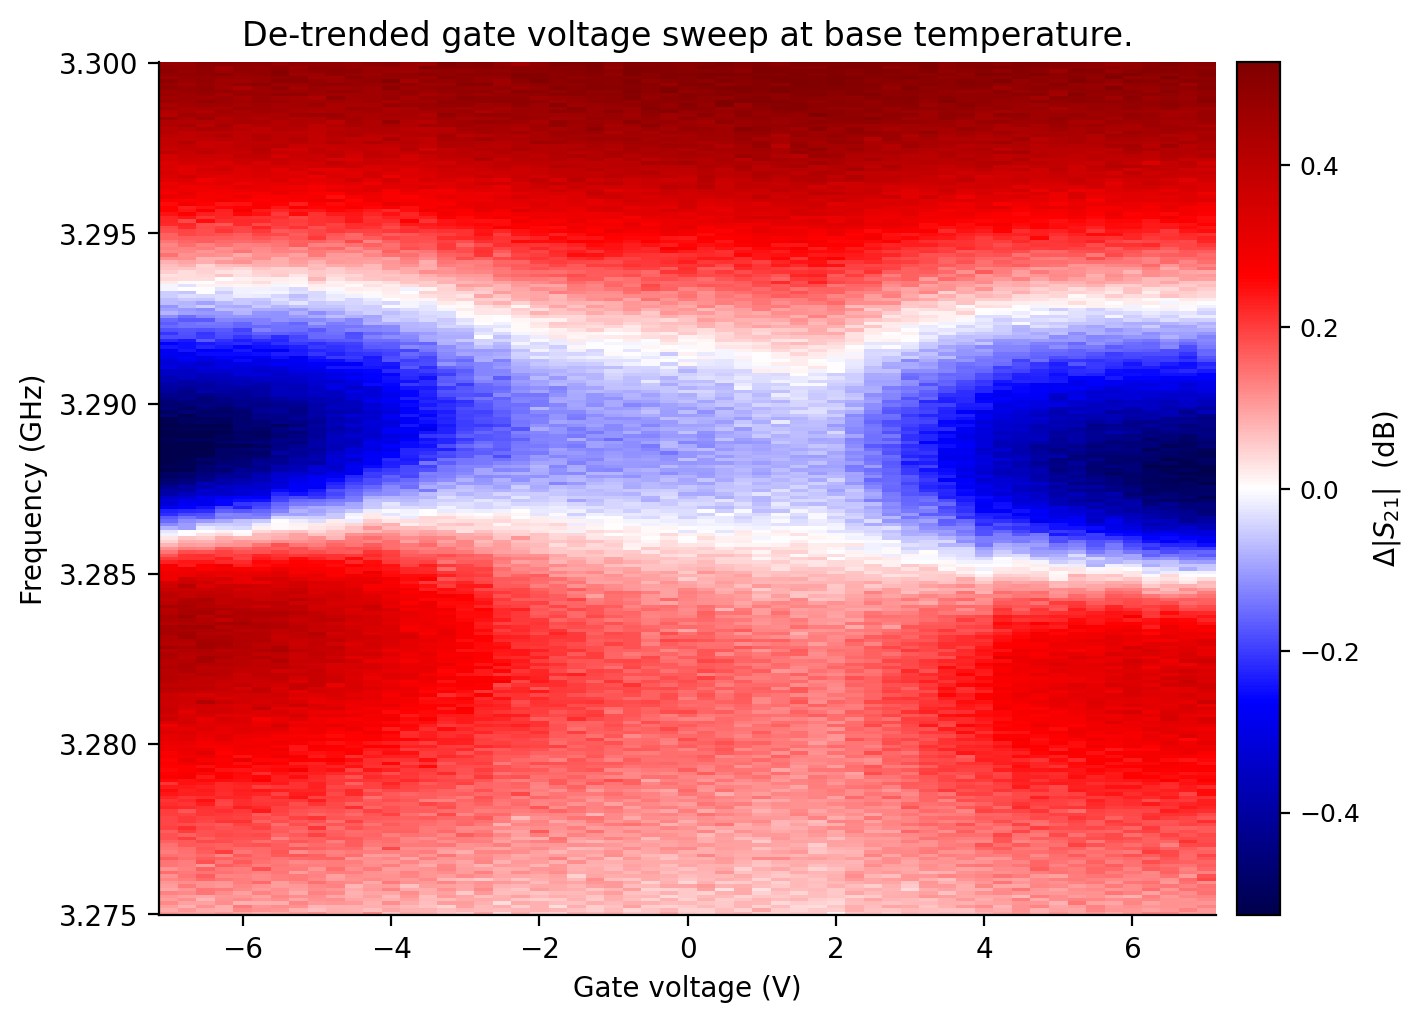

In [430]:
fig, ax = plot_2d(ds,'sample',segment=(3.275e9,3.30e9),detrend='edges',edge_frac=0.1)
ax.set_title("De-trended gate voltage sweep at base temperature.")

Text(0.5, 1.0, 'De-trended gate voltage sweep at base temperature.')

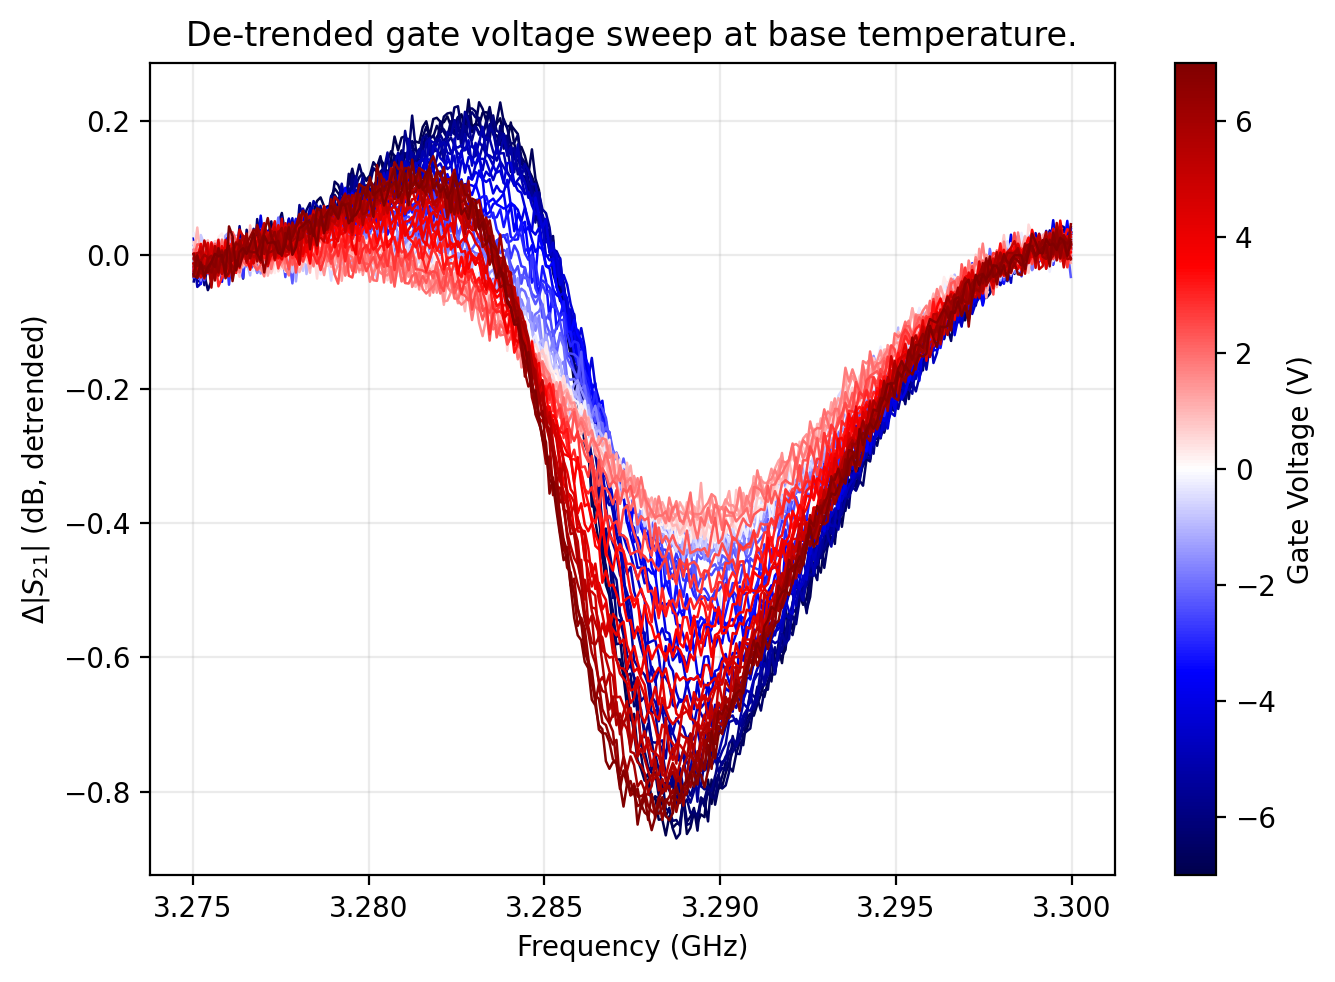

In [424]:
fig, ax = plot_linecuts_segment(ds,'sample',segment=(3.275e9,3.30e9),detrend='edges',edge_frac=0.1)
ax.set_title("De-trended gate voltage sweep at base temperature.")

# Measurement summary:

## Run summary:

### Run 6
- GUID: 967f9bbd-0000-0000-0000-01a0882d77f4
- Parameters: N/A
- Frequency band(s): Wideband sweep from 2-10GHz. 
- Comments: Broad, unidentified mode around 8.5GHz.

### Run 10
- GUID: f28ad758-0000-0000-0000-01a08852be5d
- Parameters: 0V - +3V gate bias at ~100mK
- Frequency band(s): Sample.
- Comments: Mode begins to change close to 3V.

### Run 13
- GUID: 2c3c6564-0000-0000-0000-01a088a57f09
- Parameters: -3V - +3V gate bias
- Frequency band(s): Sample.
- Comments: Assymetric around ~1.5V.

### Run 15
- GUID: 5cbd12c7-0000-0000-0000-01a08d7fa0cb
- Parameters: -3V to +3V, base to 1K.
- Frequency band(s): Sample and references.
- Comments: 

### Run 16
- GUID: 1f13dd40-0000-0000-0000-01a09270f0cd
- Parameters: Gate 0V to 5V
- Frequency band(s): Sample and references.
- Comments: Change around 3V!

### Run 23
- GUID: de20c481-0000-0000-0000-01a0929e2cdd
- Parameters: Gate leakage check.
- Frequency band(s): N/A
- Comments: Gate turn-on around 7V. Terminated sweep at 7.75V. Need to create a function that sweeps all gates and sets software limits on the SMU output.

### Run 25
- GUID: d4df29e1-0000-0000-0000-01a09307d437
- Parameters: Power sweep at (I believe) 7V gate bias.
- Frequency band(s): Sample, references, wideband, mode.
- Comments: Unidentified mode is quite power-dependent. Is this consistent with box mode?

### Run 26
- GUID: 599ab6e7-0000-0000-0000-01a09402fef3
- Parameters: Temperature sweep up to 1K, 0 to 7V gate bias.
- Frequency band(s): Samples, references, mode.
- Comments: 

### Run 28
- GUID: 9a9d9c29-0000-0000-0000-01a09782b088
- Parameters: Negative gate sweep.
- Frequency band(s): N/A
- Comments: No leakage down to -5V on gate.

### Run 29
- GUID: f2c699fe-0000-0000-0000-01a097bbd2d7
- Parameters: Negative gate sweep at base temperature.
- Frequency band(s): Sample, references, wideband.
- Comments: Similar turn-on at negative doping. Second harmonic popping out!

### Run 31
- GUID: 03b6b17b-0000-0000-0000-01a098460236
- Parameters: -7V to +7V on gate, base temperature.
- Frequency band(s): Sample, sample harmonic, references, mode.
- Comments: 

### Run 32
- GUID: a30acff4-0000-0000-0000-01a09883a3f3
- Parameters: Power sweep -10dB to +10dB
- Frequency band(s): Sample, sample harmonic, references, mode.
- Comments: Not super power dependent.

### Run 32
- GUID: e8bfe9ef-0000-0000-0000-01a09896e39d
- Parameters: Lower power sweep -40dB to 0dB.
- Frequency band(s): Sample harmonic.
- Comments: 

### Run 34
- GUID: 5821ba49-0000-0000-0000-01a099b97b41
- Parameters: Warmer temperature sweep (1.4K-2.4K) at -7V to +7V gate bias.
- Frequency band(s): Sample, sample harmonic, references, mode.
- Comments: 